#**Group A4 -- NYC Airbnb Compliance Analysis**

*   **Import the raw dataset**
*   **Clean the data**
    -   Dealing with Object Features and Missing Values
    -   Create the target feature
*   **Exploratory Data Analysis (EDA)**
    -   Dealing with the categorical features (proportion)
    -   Dealing with the numeric features (log scales & hiding outliers)
*   **Modeling**
    -   Models
        -   Decision Tree
        -   Lasso Regression
        -   Random Forest
        -   MLP Classifier
        -   SVM
        -   kNN
        -   Best Model (*)
    -   Esemble Models
        -   Hard Voting
        -   Soft Voting
    -   Profit Analysis
        -   Cost/Benefit Matrix
        -   Generating the Final Deployment Table using Out-of-Fold Predictions
        -   "True Illegal" via Monte Carlo Simulation
        -   Probability Calibration
        -   Capacity-Constrained ROI: Model-Driven vs. Random Auditing
    -   Text Analysis
        -   Naive Bayes
    -   Similarity Analysis
        -   K-means Clustering
*   **Output**



In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#**Import the raw dataset**

In [ ]:
raw_df = pd.read_csv('airbnb_listings.csv')

In [ ]:
print("Rows:",raw_df.shape[0],"Columns:",raw_df.shape[1])
raw_df.head(5)

Rows: 36111 Columns: 79


,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,40824219,https://www.airbnb.com/rooms/40824219,20251001171547,2025-10-02,city scrape,Room close to Manhattan for FEMALE guests,This cozy spacious room includes a twin size b...,Sunnyside is a safe residental area. <br />The...,https://a0.muscache.com/pictures/hosting/Hosti...,317540555,...,4.88,4.94,4.69,NaN,f,3,0,3,0,0.23
1,40833186,https://www.airbnb.com/rooms/40833186,20251001171547,2025-10-02,previous scrape,Soho LES East village private room downtown,NaN,NaN,https://a0.muscache.com/pictures/1f093bbc-936c...,68718914,...,NaN,NaN,NaN,NaN,t,1,0,1,0,NaN
2,40837137,https://www.airbnb.com/rooms/40837137,20251001171547,2025-10-02,previous scrape,Sunset Park - Quiet and close to subway!,"Cozy, lovely bedroom with a comfortable full s...",the sunset park of Brooklyn,https://a0.muscache.com/pictures/01c4e91e-4012...,317770098,...,5.00,5.00,5.00,NaN,f,1,0,1,0,0.01
3,40838018,https://www.airbnb.com/rooms/40838018,20251001171547,2025-10-02,previous scrape,Cozy One Bedroom in Clinton Hill,This sunny one-bedroom apartment is located in...,Clinton Hill is one of the best neighborhoods ...,https://a0.muscache.com/pictures/9322d54a-6eb7...,17211451,...,5.00,5.00,5.00,NaN,t,1,1,0,0,0.01
4,40839416,https://www.airbnb.com/rooms/40839416,20251001171547,2025-10-02,city scrape,🪴XL dojo 🌾 shared green yogi palace apt 🌿,"New York City living at its best. A massive, c...",Live like the Ramones > The East Village is st...,https://a0.muscache.com/pictures/hosting/Hosti...,4765305,...,5.00,5.00,4.95,NaN,f,8,0,8,0,0.40


In [ ]:
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36111 entries, 0 to 36110
Data columns (total 79 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            36111 non-null  int64  
 1   listing_url                                   36111 non-null  object 
 2   scrape_id                                     36111 non-null  int64  
 3   last_scraped                                  36111 non-null  object 
 4   source                                        36111 non-null  object 
 5   name                                          36109 non-null  object 
 6   description                                   35153 non-null  object 
 7   neighborhood_overview                         18704 non-null  object 
 8   picture_url                                   36111 non-null  object 
 9   host_id                                       36111 non-null 

#**Clean the data**

In [ ]:
df = raw_df.copy()

# Select possibly related features
df = df[[
    # --- Identification & Metadata ---
    'id',                     # Unique identifier for the listing
    'host_id',                # Unique identifier for the host

    # --- Target Variable Construction (The "Legal Logic" Fields) ---
    # These will be used to create 'is_illegal' then dropped to avoid data leakage.
    'room_type',              # To identify "Entire home/apt"
    'minimum_nights',         # To identify stays < 30 days
    'license',                # To check if the host is registered with the OSE

    # --- Host Professionalism & Commerciality (Predictors) ---
    # High values suggest "professional" operations rather than casual home sharing.
    'host_acceptance_rate',                           # High rates suggest revenue maximization
    'host_is_superhost',                              # Indicates high service standards for commercial gain
    'host_neighbourhood',                             # Host location
    'calculated_host_listings_count_entire_homes',    # Specific count of high-risk "entire home" units
    'calculated_host_listings_count_private_rooms',   # Count of private room inventory

    # --- Pricing & Economic Motivation ---
    'price',                          # Signals illegal short-term premiums
    'estimated_revenue_l365d',        # Potential ROI driving non-compliance

    # --- Activity & Turnover (Occupancy Proxies) ---
    # High turnover is a hallmark of short-term rentals vs. long-term residency.
    'availability_365',               # Measures if the unit is a dedicated business
    'number_of_reviews_ltm',          # Review frequency indicates guest turnover
    'number_of_reviews_l30d',         # Very recent activity

    # --- Location & Market Hotspots ---
    # Used to identify geographical ROI "hotspots".
    'neighbourhood_cleansed',         # Specific neighborhood for community impact
    'neighbourhood_group_cleansed',   # The Borough (totally 5)

    # --- Operational Features ---
    'instant_bookable',                # Used by operators to automate high volume

    # --- Location on Map ---
    'latitude',                       # For mapping and spatial analysis
    'longitude'                      # For mapping and spatial analysis
]]

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36111 entries, 0 to 36110
Data columns (total 20 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            36111 non-null  int64  
 1   host_id                                       36111 non-null  int64  
 2   room_type                                     36111 non-null  object 
 3   minimum_nights                                36111 non-null  int64  
 4   license                                       5376 non-null   object 
 5   host_acceptance_rate                          20516 non-null  object 
 6   host_is_superhost                             35727 non-null  object 
 7   host_neighbourhood                            27627 non-null  object 
 8   calculated_host_listings_count_entire_homes   36111 non-null  int64  
 9   calculated_host_listings_count_private_rooms  36111 non-null 

## **Dealing with Object Features and Missing Values**

To ensure the accuracy of the subsequent Exploratory Data Analysis (EDA) and to align with the regulatory context of **Local Law 18 (LL18)**, we have adopted differentiated cleaning strategies based on the physical meaning and business relevance of each feature:

1. **`price` (Core Economic Metric)**:
   - **Action**: Missing values are prioritized for imputation using the **median price** of the specific neighborhood (`neighbourhood_cleansed`). This preserves data volume while respecting the significant geographical price variations across NYC (e.g., Manhattan vs. Bronx).

2. **`host_acceptance_rate` (Professionalism Indicator)**:
   - **Action**: Missing values may represent inactive hosts or those prioritizing privacy over platform transparency. We create a new binary feature, `has_acceptance_rate` (1 if data exists, 0 if missing), to analyze if the absence of this metric correlates with non-compliance. For the original rate, we keep it as-is (NaN) during visualization to ensure the Boxplot reflects the true distribution of active market participants. Later we will fill it with -1 OR "Differentiated Imputation" depends on `host_is_superhost` (considering).

3. **`estimated_revenue_l365d` (ROI Driving Force)**:
   - **Action**: Since this value is typically missing when price or reviews are absent, we fill it with `0`, assuming no market revenue was generated in the past year.

4. **`host_is_superhost` (Service Standard)**:
   - **Action**: For the minimal missing values, we use the **mode** (typically 'f') for imputation to maintain feature integrity for classification. Mapped 't' to `1` and 'f' to `0`.

5. **`instant_bookable` (Operational Efficiency)**:
   - **Action**: Mapped 't' to `1` and 'f' to `0`. This feature is often used by commercial operators to automate bookings.

6. **`neighbourhood_group_cleansed` (Geographic Segmentation)**:
   - **Action**: Converted into **dummy variables** (1/0) to allow for borough-specific statistical analysis in later stages.

7. **`license` (Regulatory Standardization)**:
   - **Action**: Standardized all entries containing "ose" (case-insensitive) to "OSE". This unifies various Office of Special Enforcement labels into a single category, facilitating clearer analysis of government-monitored listings.

In [ ]:
# --- Data Cleaning & Imputation ---

# 1. Process 'price': Convert to numeric and impute by neighborhood median
# Remove currency symbols and commas first
df['price'] = df['price'].astype(str).str.replace('$', '', regex=False).str.replace(',', '', regex=False)
df['price'] = pd.to_numeric(df['price'], errors='coerce')

# Impute missing prices based on the median of their specific neighborhood
df['price'] = df.groupby('neighbourhood_cleansed')['price'].transform(lambda x: x.fillna(x.median()))
# Fallback to global median if a specific neighborhood has no price data at all
df['price'] = df['price'].fillna(df['price'].median())

# 2. Process 'host_acceptance_rate': Convert percentage to float and Create the new feature
df['host_acceptance_rate'] = df['host_acceptance_rate'].astype(str).str.replace('%', '', regex=False)
df['host_acceptance_rate'] = pd.to_numeric(df['host_acceptance_rate'], errors='coerce') / 100
df['has_acceptance_rate'] = df['host_acceptance_rate'].notnull().astype(int)

# 3. Process 'estimated_revenue_l365d': Fill missing with 0
df['estimated_revenue_l365d'] = df['estimated_revenue_l365d'].fillna(0)

# 4. Process 'host_is_superhost': Fill with mode and map to binary (0/1)
superhost_mode = df['host_is_superhost'].mode()[0]
df['host_is_superhost'] = df['host_is_superhost'].fillna(superhost_mode)
df['host_is_superhost'] = df['host_is_superhost'].map({'t': 1, 'f': 0}).astype(int)
# Verify the cleaning results
cols_to_check = ['price', 'host_acceptance_rate', 'estimated_revenue_l365d', 'host_is_superhost']
print("Missing values count after targeted cleaning:")
print(df[cols_to_check].isnull().sum())

# 5. Process 'instant_bookable': Map t/f to 1/0
df['instant_bookable'] = df['instant_bookable'].map({'t': 1, 'f': 0}).fillna(0).astype(int)

# 6. Process 'neighbourhood_group_cleansed': Convert to dummy variables
df = pd.get_dummies(df, columns=['neighbourhood_group_cleansed'], prefix='Borough', dtype=int)

# 7. Standardize 'license' names: Convert any entry containing "ose" (case-insensitive) to "OSE"
# We use case=False to catch 'ose', 'Ose', 'OSE', etc.
df.loc[df['license'].str.contains('ose', case=False, na=False), 'license'] = 'OSE'
# Verify the cleaning results
print("\nSample of cleaned license values:")
print(df['license'].value_counts().head(5))

Missing values count after targeted cleaning:
price                          0
host_acceptance_rate       15595
estimated_revenue_l365d        0
host_is_superhost              0
dtype: int64

Sample of cleaned license values:
license
Exempt    3106
OSE       2270
Name: count, dtype: int64


In [ ]:
# Rename Borough_Staten Island
df.rename(columns={'Borough_Staten Island': 'Borough_Staten_Island'}, inplace=True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36111 entries, 0 to 36110
Data columns (total 25 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            36111 non-null  int64  
 1   host_id                                       36111 non-null  int64  
 2   room_type                                     36111 non-null  object 
 3   minimum_nights                                36111 non-null  int64  
 4   license                                       5376 non-null   object 
 5   host_acceptance_rate                          20516 non-null  float64
 6   host_is_superhost                             36111 non-null  int64  
 7   host_neighbourhood                            27627 non-null  object 
 8   calculated_host_listings_count_entire_homes   36111 non-null  int64  
 9   calculated_host_listings_count_private_rooms  36111 non-null 

##**Create the target feature**

In [ ]:
# Create the target feature

# ==================================================================================================================
# 1. This law requires all short-term rental hosts to register with the Mayor’s Office of Special Enforcement (OSE).
# 2. Also, it prohibits rentals of an entire apartment for less than 30 days unless the host is physically present
#    in the home during the stay.
# ==================================================================================================================

df['is_illegal'] = (
    ((df['license'].isnull()) & (df['minimum_nights'] < 30)) |
    ((df['room_type'] == 'Entire home/apt') & (df['minimum_nights'] < 30) &
    (df['host_neighbourhood'] != df['neighbourhood_cleansed']))
).astype(int)

# Display the count of illegal listings and their proportion
print(df['is_illegal'].value_counts())
print(f"Proportion of illegal listings: {df['is_illegal'].mean():.2f}")

is_illegal
0    35031
1     1080
Name: count, dtype: int64
Proportion of illegal listings: 0.03


In [ ]:
df.head(5)

,id,host_id,room_type,minimum_nights,license,host_acceptance_rate,host_is_superhost,host_neighbourhood,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,...,instant_bookable,latitude,longitude,has_acceptance_rate,Borough_Bronx,Borough_Brooklyn,Borough_Manhattan,Borough_Queens,Borough_Staten_Island,is_illegal
0,40824219,317540555,Private room,30,NaN,0.54,1,Sunnyside,0,3,...,0,40.74698,-73.91763,1,0,0,0,1,0,0
1,40833186,68718914,Private room,30,NaN,NaN,0,NaN,0,1,...,1,40.72314,-73.99323,0,0,0,1,0,0,0
2,40837137,317770098,Private room,30,NaN,NaN,0,Sunset Park,0,1,...,0,40.64607,-74.00552,0,0,1,0,0,0,0
3,40838018,17211451,Entire home/apt,90,NaN,NaN,0,Clinton Hill,1,0,...,1,40.68370,-73.96115,0,0,1,0,0,0,0
4,40839416,4765305,Private room,30,NaN,0.69,1,Alphabet City,0,8,...,0,40.72147,-73.98270,1,0,0,1,0,0,0


#**Exploratory Data Analysis**

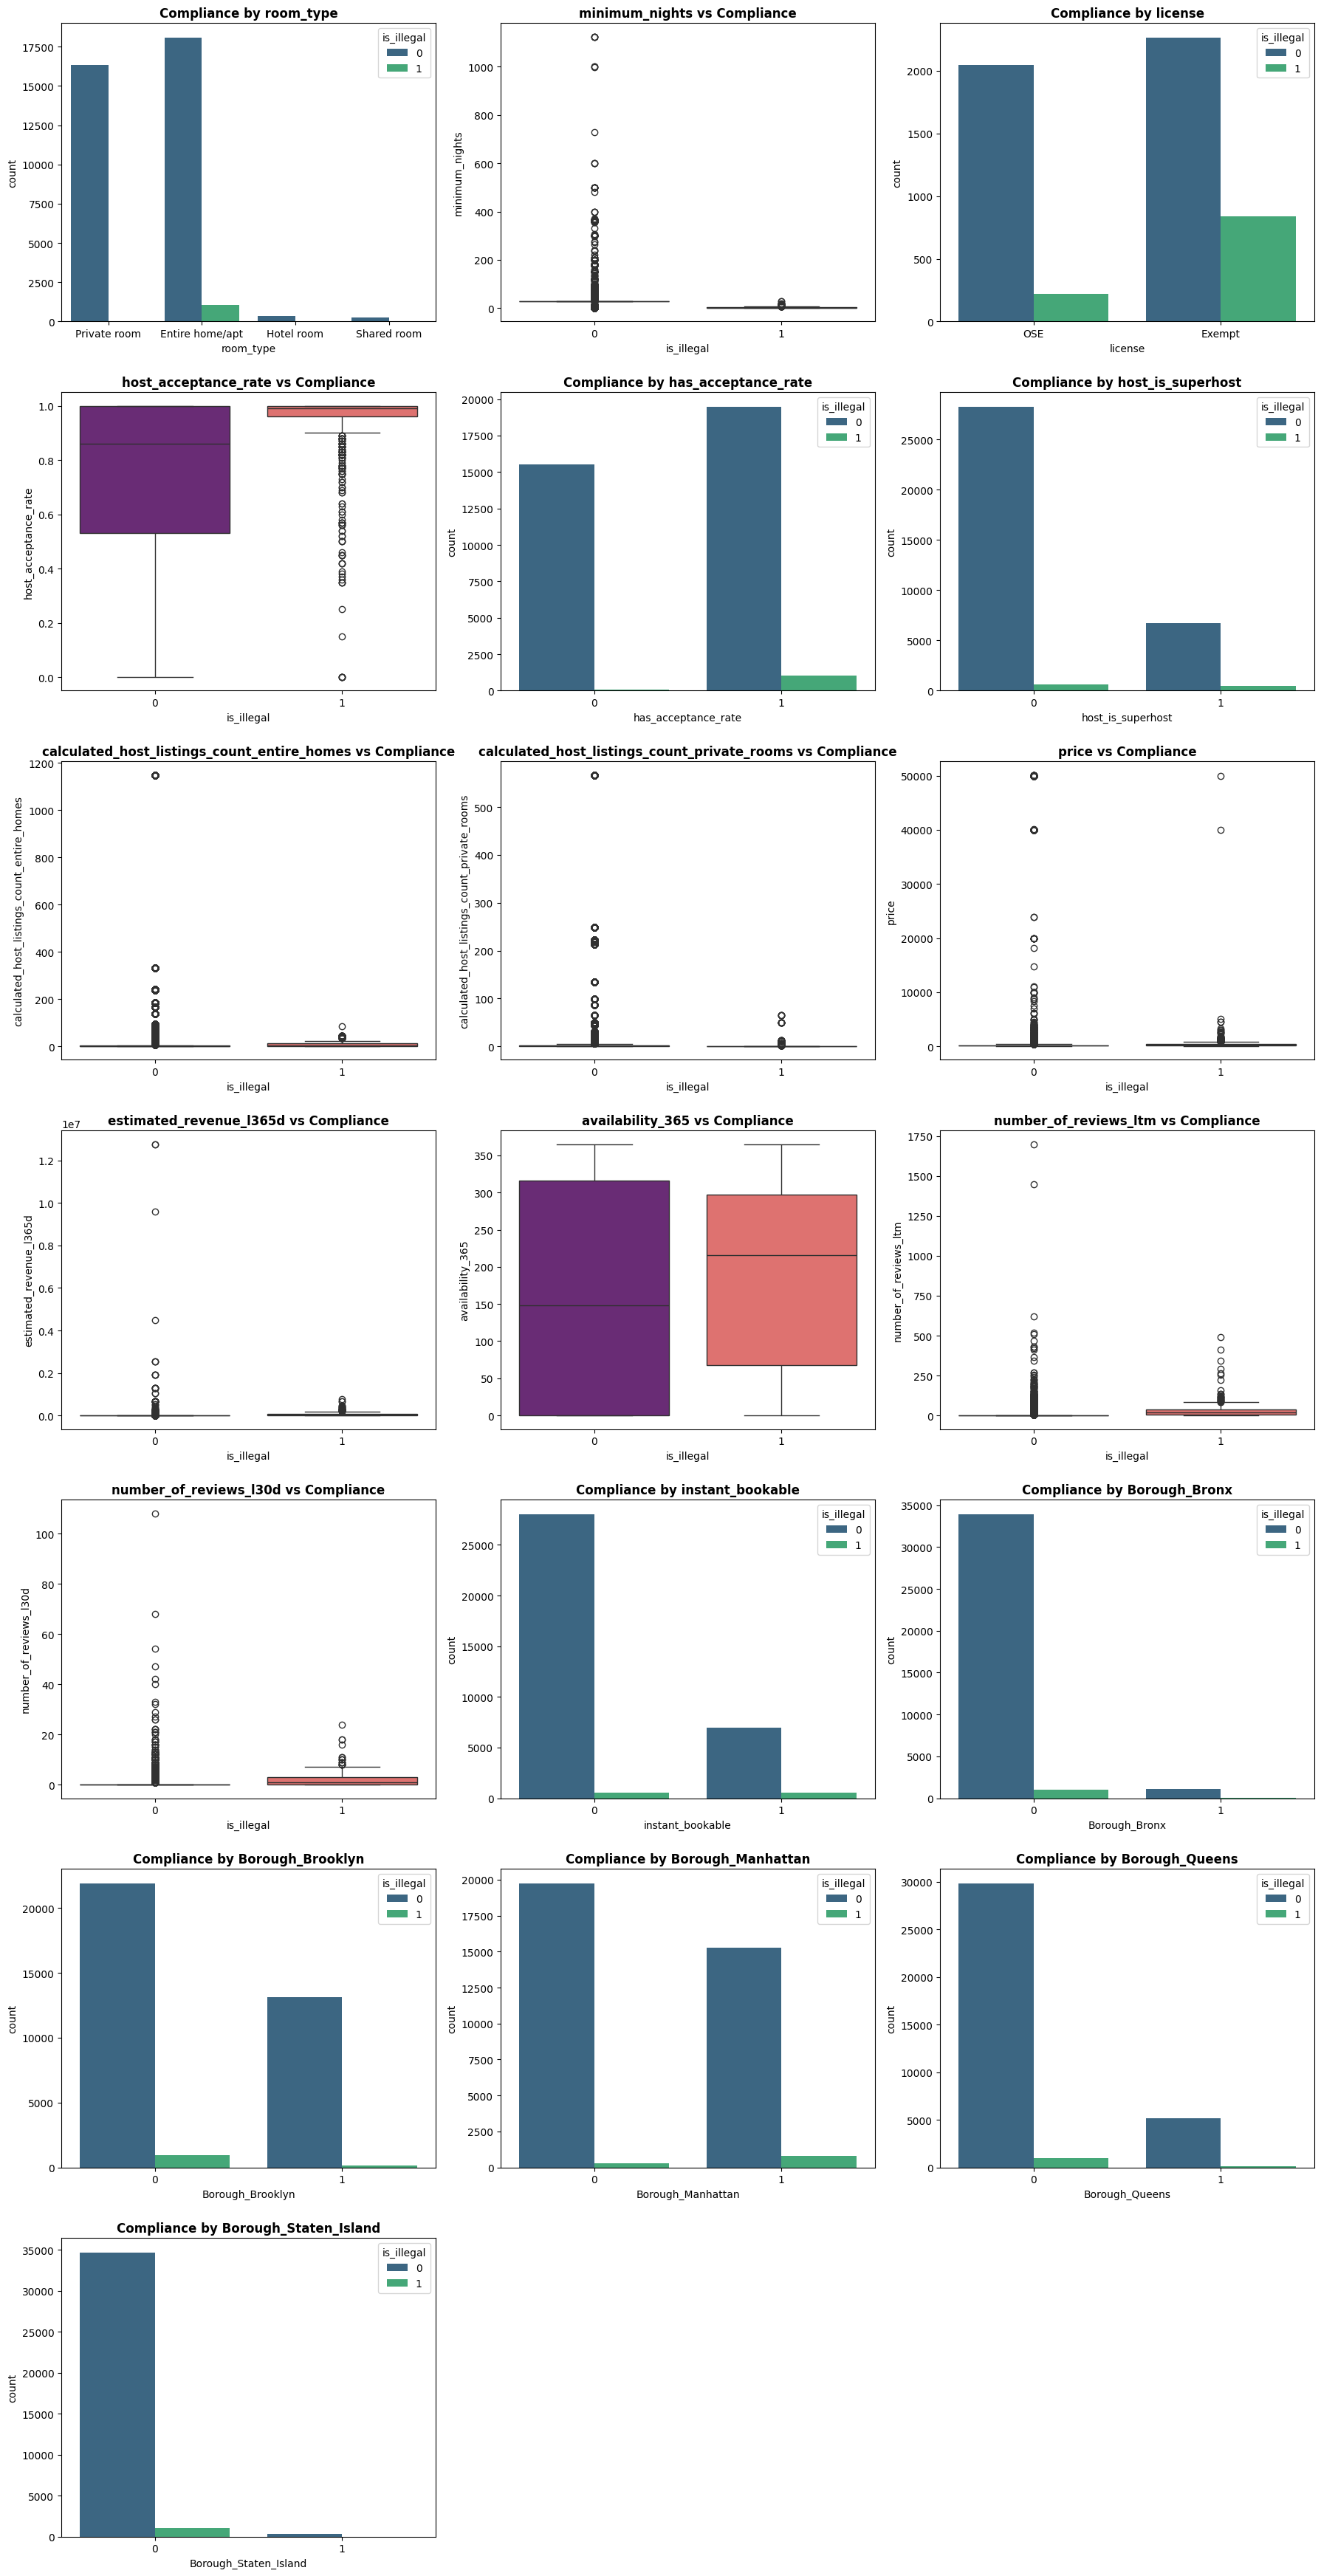

In [ ]:
# Define the list of features provided for analysis
features_to_analyze = [
    'room_type', 'minimum_nights', 'license', 'host_acceptance_rate',
    'has_acceptance_rate', 'host_is_superhost',
    'calculated_host_listings_count_entire_homes',
    'calculated_host_listings_count_private_rooms', 'price',
    'estimated_revenue_l365d', 'availability_365',
    'number_of_reviews_ltm', 'number_of_reviews_l30d',
    'instant_bookable', 'Borough_Bronx', 'Borough_Brooklyn',
    'Borough_Manhattan', 'Borough_Queens', 'Borough_Staten_Island'
]

# Configure the plotting grid
n_cols = 3
n_rows = (len(features_to_analyze) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = axes.flatten()

# Iterate through features and generate appropriate visualizations
for i, col in enumerate(features_to_analyze):
    if col not in df.columns:
        continue

    # Check for categorical or binary features (typically <= 5 unique values)
    if df[col].nunique() <= 5:
        # Use Countplot for categorical features to see the ratio of is_illegal
        sns.countplot(data=df, x=col, hue='is_illegal', ax=axes[i], palette='viridis')
        axes[i].set_title(f'Compliance by {col}', fontsize=12, fontweight='bold')
        axes[i].legend(title='is_illegal', loc='upper right')
    else:
        # Use Boxplot for continuous numerical features
        sns.boxplot(data=df, x='is_illegal', y=col, ax=axes[i],
                    hue='is_illegal', palette='magma', showfliers=True, legend=False)
        axes[i].set_title(f'{col} vs Compliance', fontsize=12, fontweight='bold')

# Final layout adjustments: remove unused axes and tighten layout
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

##Deal with the categorical features (proportion)

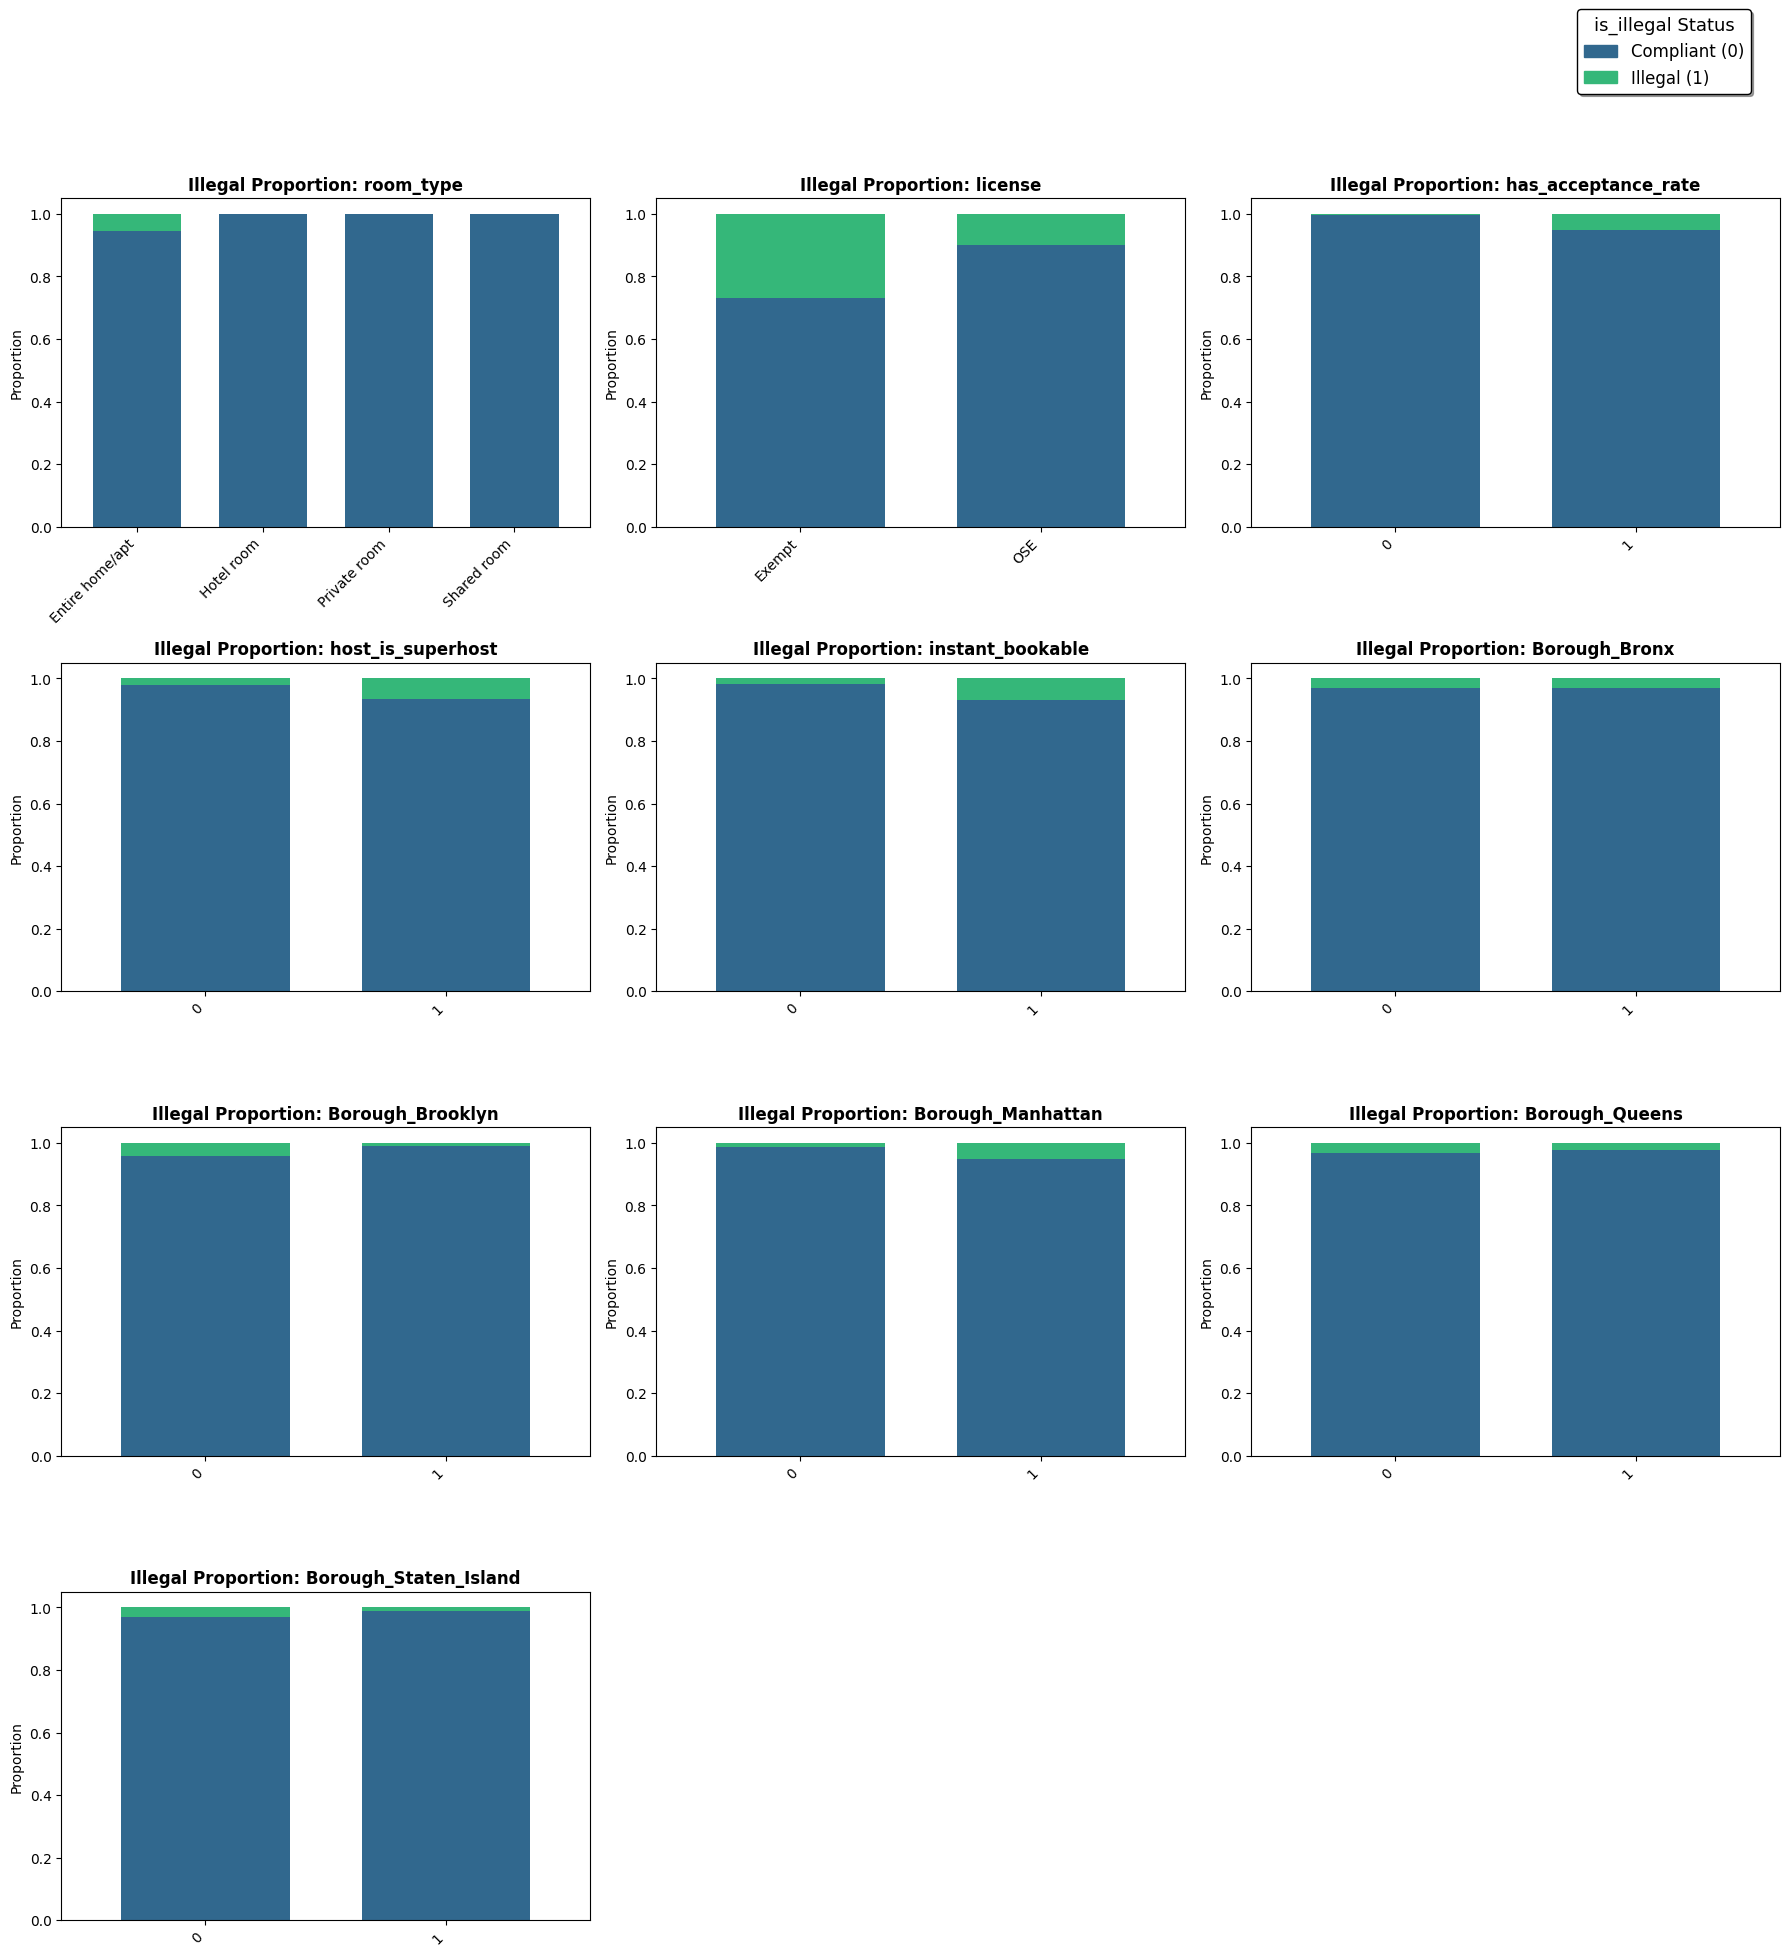

In [ ]:
# Select only the features that were previously shown as countplots (Categorical/Binary)
categorical_cols = [col for col in features_to_analyze if col in df.columns and df[col].nunique() <= 5]

# Configure the plotting grid
n_cat_cols = 3
n_cat_rows = (len(categorical_cols) + n_cat_cols - 1) // n_cat_cols
fig, axes = plt.subplots(n_cat_rows, n_cat_cols, figsize=(18, 5 * n_cat_rows), dpi=100) # Fixed DPI
axes = axes.flatten()

# Iterate through categorical columns to create normalized stacked bars
colors = sns.color_palette("viridis", 2)

# Iterate and plot
for i, col in enumerate(categorical_cols):
    # Normalize data per category
    proportions = df.groupby(col)['is_illegal'].value_counts(normalize=True).unstack().fillna(0)

    # We explicitly TURN OFF the individual legends here
    proportions.plot(kind='bar', stacked=True, ax=axes[i], color=colors, width=0.7, legend=False)

    # Customizing plot aesthetics for stability
    axes[i].set_title(f'Illegal Proportion: {col}', fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Proportion')
    axes[i].set_xlabel('') # Clear x-label to reduce clutter
    axes[i].set_ylim(0, 1.05) # Fix Y-axis range

    # Align X-axis labels to prevent shaking
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45, ha='right', fontsize=10)

# Remove unused subplot axes
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Create global legend on the top right
import matplotlib.patches as mpatches
compliant_patch = mpatches.Patch(color=colors[0], label='Compliant (0)')
illegal_patch = mpatches.Patch(color=colors[1], label='Illegal (1)')
fig.legend(handles=[compliant_patch, illegal_patch], title='is_illegal Status',
           loc='upper right', bbox_to_anchor=(0.98, 0.98), fontsize=12, title_fontsize=13,
           frameon=True, edgecolor='black', shadow=True)

plt.tight_layout(rect=[0, 0, 1, 0.90])
plt.show()

## Deal with the numeric features (log scales & hiding outliers)

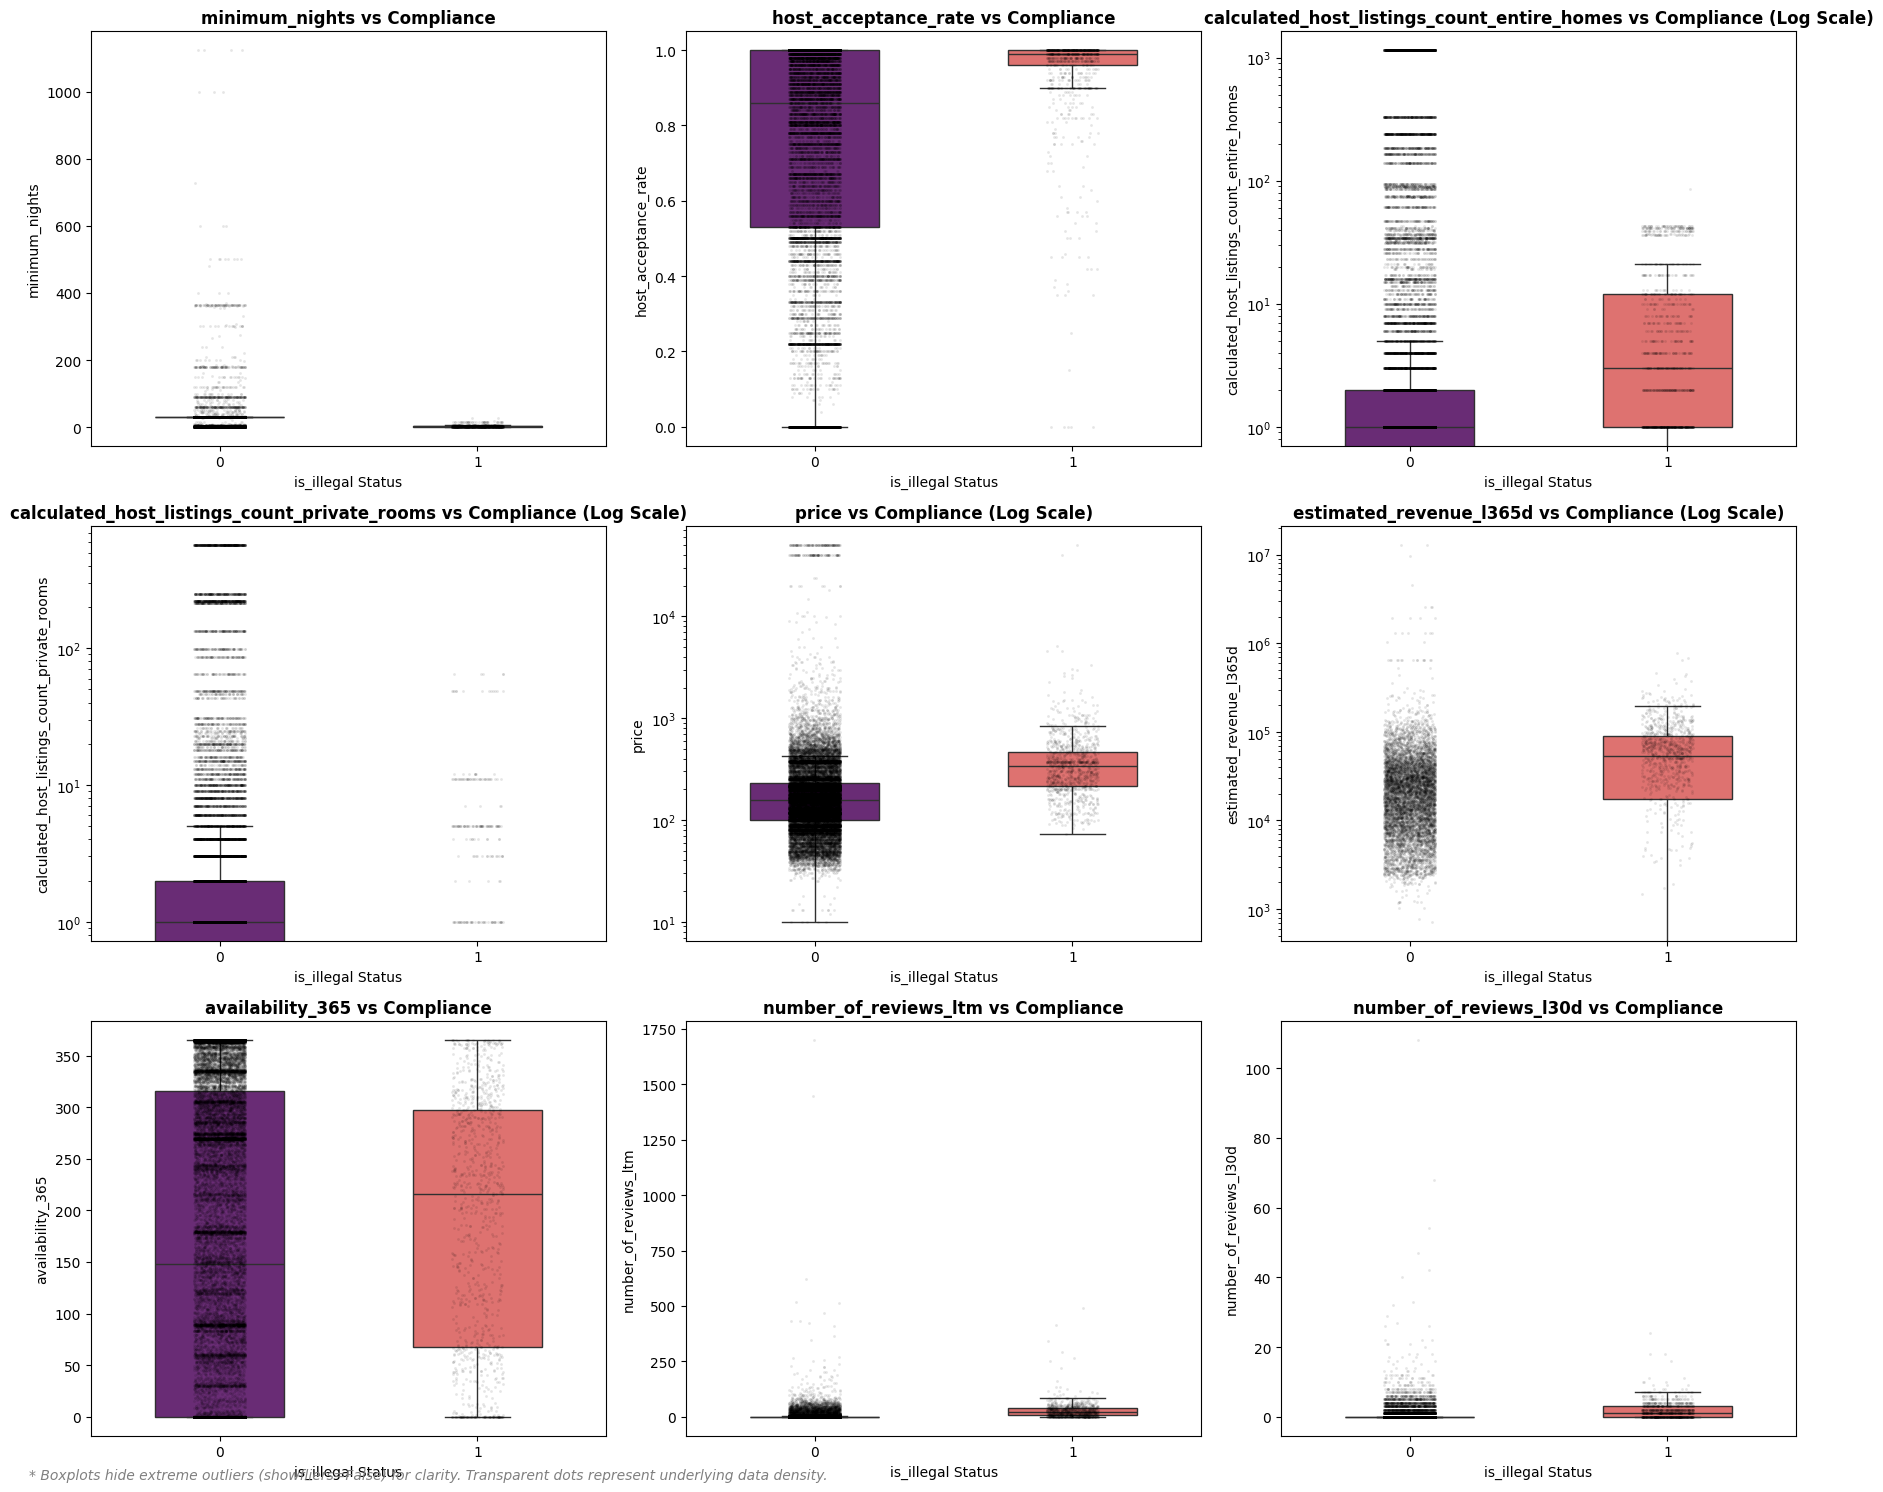

In [ ]:
# Identify continuous numerical features
numerical_cols = [col for col in features_to_analyze if col in df.columns and df[col].nunique() > 5]

# Configure the plotting grid for Numerical Features
n_num_cols = 3
n_num_rows = (len(numerical_cols) + n_num_cols - 1) // n_num_cols
fig, axes = plt.subplots(n_num_rows, n_num_cols, figsize=(18, 5 * n_num_rows), dpi=100)
axes = axes.flatten()

# Define professional color palette
# Using the same 'magma' palette for consistency with your previous plots
colors = sns.color_palette("magma", 2)

for i, col in enumerate(numerical_cols):
    # Determine if Log Scale is needed (Professional choice for high-skew features)
    # Price and Revenue often span multiple orders of magnitude
    use_log = any(keyword in col.lower() for keyword in ['price', 'revenue', 'listings_count'])

    # Create the Boxplot (Hiding outliers to keep the "box" visible and clear)
    sns.boxplot(
        data=df, x='is_illegal', y=col, ax=axes[i],
        hue='is_illegal', palette='magma',
        showfliers=False,  # Hide extreme outliers to focus on the interquartile range
        width=0.5, legend=False
    )

    # Overlay a transparent Strip Plot
    sns.stripplot(
        data=df, x='is_illegal', y=col, ax=axes[i],
        color='black', alpha=0.1, size=2, jitter=True
    )

    # Apply Log Scale for skewed financial data
    if use_log:
        # Note: log1p ensures we don't crash on zero values (log(0) is undefined)
        axes[i].set_yscale('log')
        axes[i].set_title(f'{col} vs Compliance (Log Scale)', fontsize=12, fontweight='bold')
    else:
        axes[i].set_title(f'{col} vs Compliance', fontsize=12, fontweight='bold')

    axes[i].set_xlabel('is_illegal Status', fontsize=10)
    axes[i].set_ylabel(col, fontsize=10)

# Remove unused axes
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Add a professional note about the visualization technique
fig.text(0.01, 0.01, "* Boxplots hide extreme outliers (showfliers=False) for clarity. Transparent dots represent underlying data density.",
         fontsize=10, style='italic', color='gray')

plt.tight_layout()
plt.show()

In [ ]:
!pip install contextily

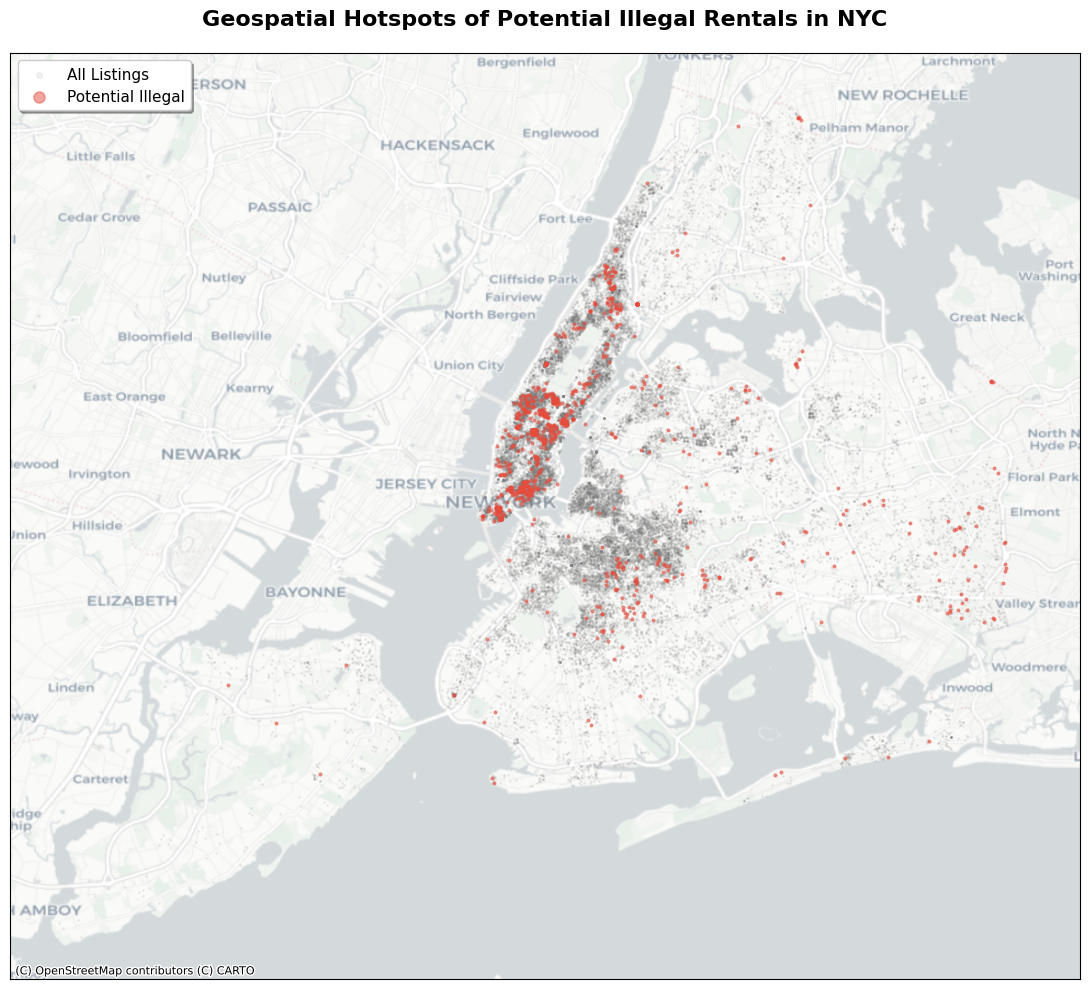

In [ ]:
import contextily as ctx

# Setup the figure and axis
fig, ax = plt.subplots(figsize=(11, 10))

# Filter data: All listings and Illegal listings
plot_df = df.copy()
illegal_df = plot_df[plot_df['is_illegal'] == 1]

# Plot All Listings as background (subtle grey)
ax.scatter(plot_df['longitude'], plot_df['latitude'],
           c='grey', s=1, alpha=0.1, label='All Listings')
# Plot Illegal Listings as hotspots (vibrant red/orange)
ax.scatter(illegal_df['longitude'], illegal_df['latitude'],
           c='#e74c3c', s=4, alpha=0.5, label='Potential Illegal')

# Add the basemap
ctx.add_basemap(ax, crs='epsg:4326', source=ctx.providers.CartoDB.Positron)

# Formatting the map
ax.set_title('Geospatial Hotspots of Potential Illegal Rentals in NYC', fontsize=16, fontweight='bold', pad=20)
ax.legend(loc='upper left', markerscale=4, fontsize=11, frameon=True, shadow=True)
ax.set_xticks([])
ax.set_yticks([])

plt.tight_layout()
plt.show()

##Correlation

In highly imbalanced datasets (e.g., only 3% illegal listings here), global correlation coefficients are often diluted by the dominant majority class, making them **poor indicators** of feature importance. Under such conditions, Boxplots provide a much more persuasive and accurate visualization, as they clearly reveal the separation in medians and distribution ranges between the two classes regardless of their sample size differences.

However, here we can **make the df balanced** and analyze the correlation.

In [ ]:
# --- Create a Balanced DataFrame (Downsampling) ---
# Separate the classes
df_illegal = df[df['is_illegal'] == 1]
df_compliant = df[df['is_illegal'] == 0]

# Sample from the compliant group to match the number of illegal cases
df_compliant_balanced = df_compliant.sample(n=len(df_illegal), random_state=42)

# Combine them into a new correlation dataframe
corr_df_balanced = pd.concat([df_illegal, df_compliant_balanced])

In [ ]:
corr_features =[
    'is_illegal', 'minimum_nights', 'host_acceptance_rate',
    'has_acceptance_rate', 'host_is_superhost',
    'calculated_host_listings_count_entire_homes',
    'calculated_host_listings_count_private_rooms', 'price',
    'estimated_revenue_l365d', 'availability_365',
    'number_of_reviews_ltm', 'number_of_reviews_l30d',
    'instant_bookable', 'Borough_Bronx', 'Borough_Brooklyn',
    'Borough_Manhattan', 'Borough_Queens', 'Borough_Staten_Island'
]

Correlation (Pearson)

Pearson Correlation measures the strength and direction of a linear relationship between two variables, but it is highly sensitive to extreme outliers and skewed data, which often leads to a coefficient near zero in Airbnb datasets.

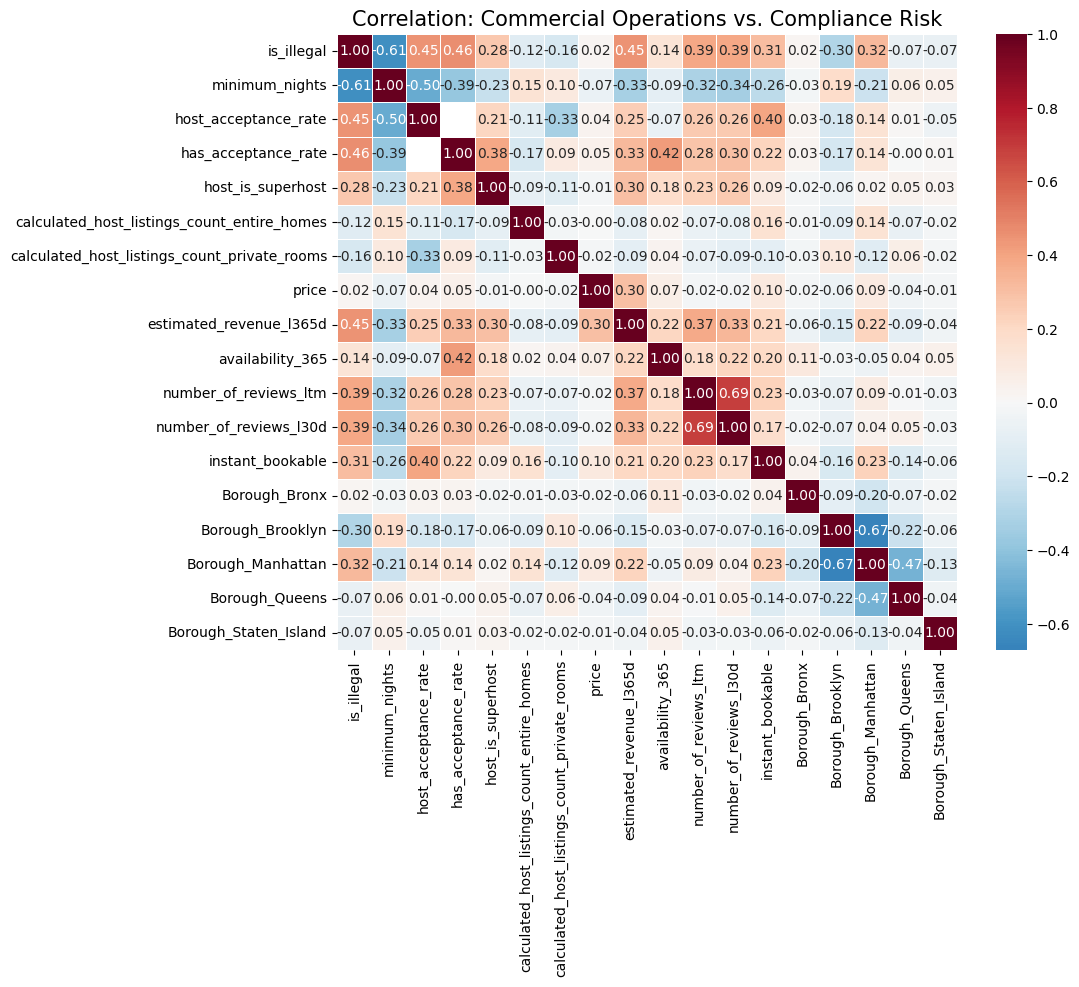

In [ ]:
# Compute the correlation matrix
plt.figure(figsize=(10, 8))
corr_matrix = corr_df_balanced[corr_features].corr()

# Plot the heatmap
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0, fmt='.2f', linewidths=0.5)
plt.title('Correlation: Commercial Operations vs. Compliance Risk', fontsize=15)
plt.show()

Correlation (Spearman)

Spearman's rank correlation is used because it is more robust to extreme outliers and skewed distributions (like price and revenue) and can capture non-linear, monotonic relationships that Pearson's correlation might miss.

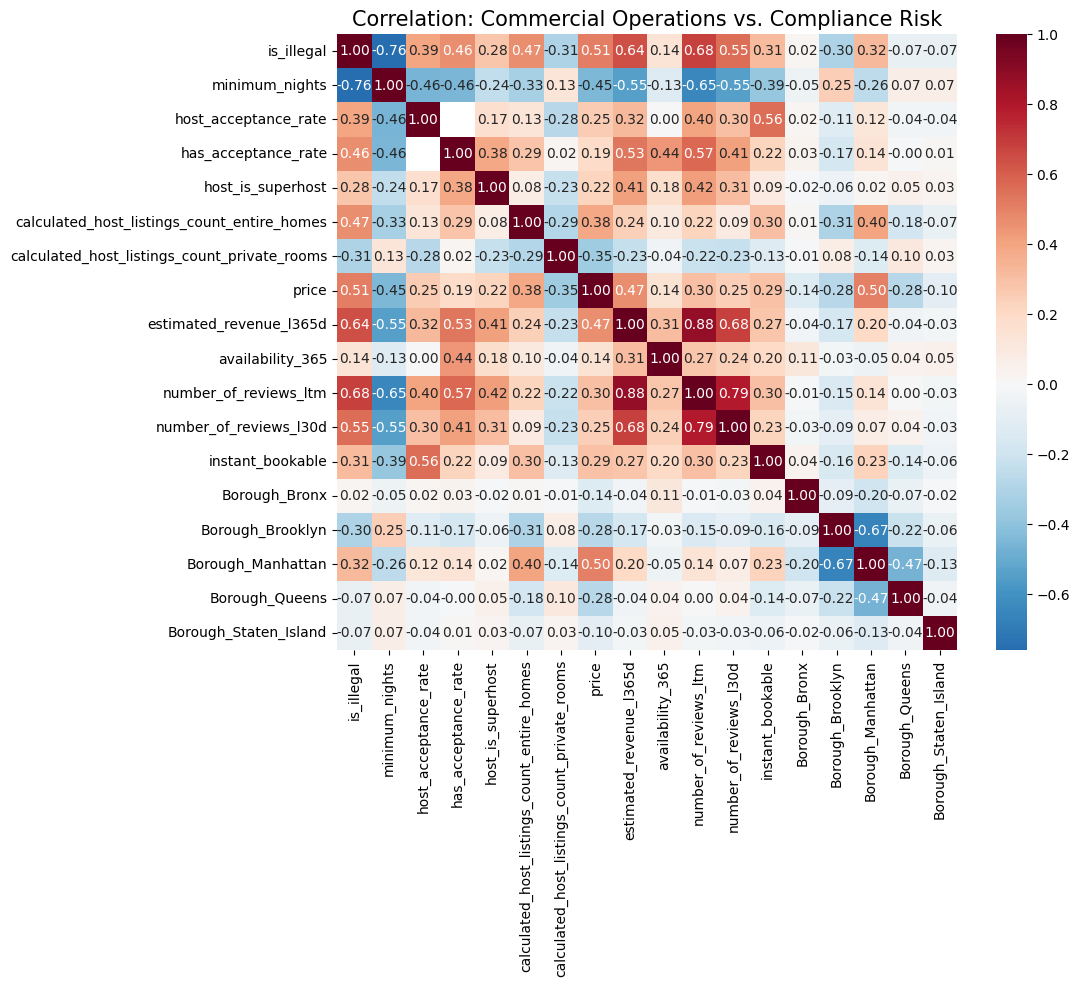

In [ ]:
# Compute the correlation matrix
plt.figure(figsize=(10, 8))
corr_matrix_2 = corr_df_balanced[corr_features].corr(method='spearman')

# Plot the heatmap
sns.heatmap(corr_matrix_2, annot=True, cmap='RdBu_r', center=0, fmt='.2f')
plt.title('Correlation: Commercial Operations vs. Compliance Risk', fontsize=15)
plt.show()

Now comming back to figure out the relationship between `host_acceptance_rate` and `host_is_superhost`.

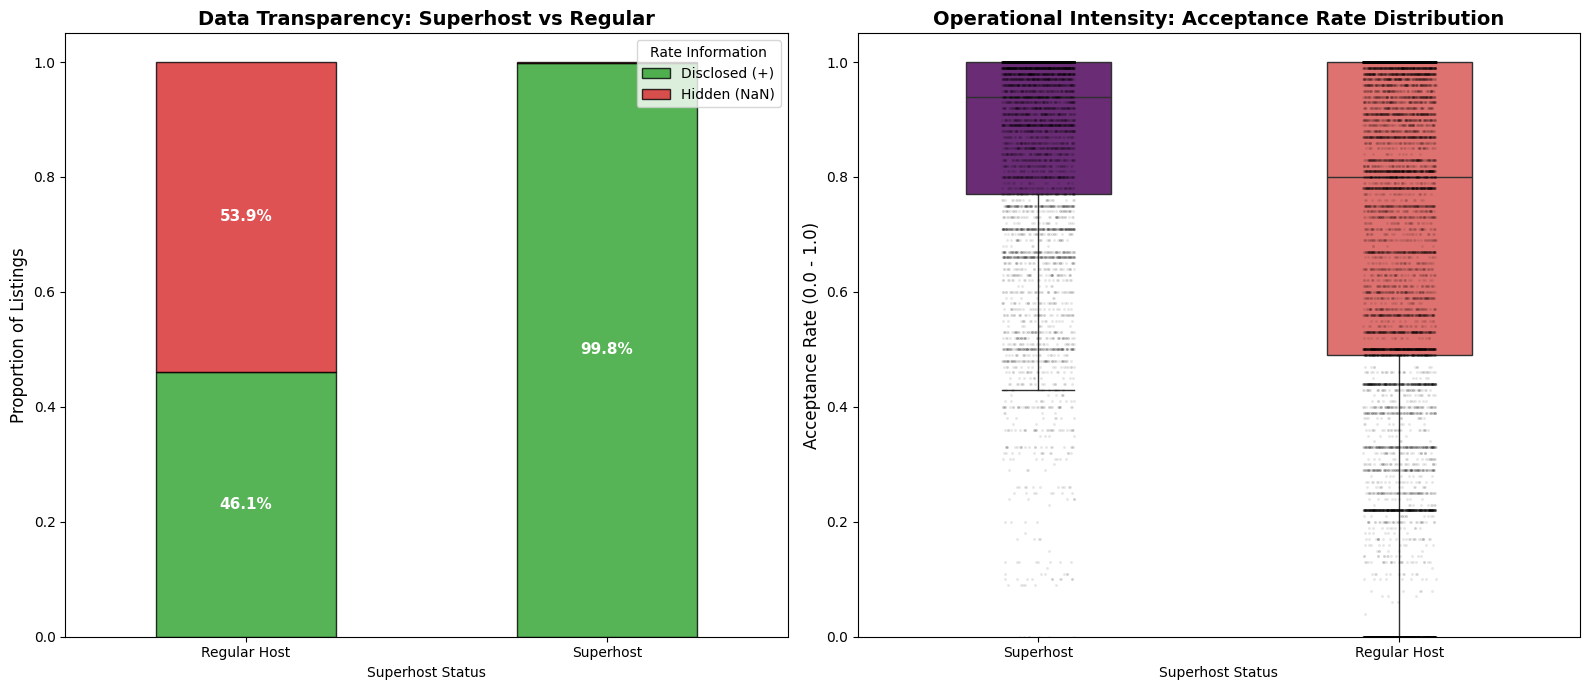

In [ ]:
plot_df_2 = df.copy()

# Categorize the 'missingness' of the acceptance rate to reveal hiding patterns
plot_df_2['Acceptance Status'] = plot_df_2['host_acceptance_rate'].apply(
    lambda x: 'Hidden (NaN)' if x == -1 or pd.isna(x) else 'Disclosed (+)'
)

# Convert binary superhost status back to readable labels for the plot
plot_df_2['Superhost Status'] = plot_df_2['host_is_superhost'].map({1: 'Superhost', 0: 'Regular Host'})

# --- Initialize the Plotting Grid ---
# Using 1 row and 2 columns to compare transparency and distribution side-by-side
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# --- Plot A: Transparency Analysis (Stacked Bar Chart) ---
# Goal: Check if Regular Hosts are more likely to hide their acceptance rates
transparency_counts = plot_df_2.groupby(['Superhost Status', 'Acceptance Status']).size().unstack(fill_value=0)
transparency_props = transparency_counts.div(transparency_counts.sum(axis=1), axis=0)

transparency_props.plot(kind='bar', stacked=True, ax=axes[0], color=['#2ca02c', '#d62728'], edgecolor='black', alpha=0.8)
axes[0].set_title('Data Transparency: Superhost vs Regular', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Proportion of Listings', fontsize=12)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
axes[0].legend(title='Rate Information', loc='upper right')

# Adding percentage labels on the bars for clarity
for p in axes[0].patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy()
    if height > 0.05: # Only label segments larger than 5%
        axes[0].text(x + width/2, y + height/2, f'{height:.1%}', ha='center', va='center',
                     fontsize=11, color='white', fontweight='bold')

# --- Plot B: Distribution Analysis (Boxplot + Strip Plot) ---
# Goal: For hosts who DO disclose rates, how does their professionalism compare?
# Filter out the placeholder/missing values (-1 or NaN) for a clean distribution
valid_data = plot_df_2[(plot_df_2['host_acceptance_rate'] != -1) & (plot_df_2['host_acceptance_rate'].notnull())]

sns.boxplot(data=valid_data, x='Superhost Status', y='host_acceptance_rate', hue='Superhost Status',
            ax=axes[1], palette='magma', width=0.4, showfliers=False, legend=False)

# Overlay a strip plot to show the density of data points
sns.stripplot(data=valid_data, x='Superhost Status', y='host_acceptance_rate',
              ax=axes[1], color='black', alpha=0.1, size=2, jitter=True)

axes[1].set_title('Operational Intensity: Acceptance Rate Distribution', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Acceptance Rate (0.0 - 1.0)', fontsize=12)
axes[1].set_ylim(0, 1.05) # Keep the scale between 0% and 100%

# --- Final Layout Adjustment ---
plt.tight_layout()
plt.show()

#**Modeling**

##Models:
1. Decision tree
2. Lasso Regression
3. Random Forest
4. MLP Classifier
5. SVM
6. kNN

Evaluation metric: AUC

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils import resample
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from google.colab import files
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix

In [ ]:
# Create the model_df for future modeling
model_df = df.copy()

model_df.drop(columns=['room_type', 'minimum_nights', 'license',
                       'host_neighbourhood', 'neighbourhood_cleansed'
                       ], inplace=True)

In [ ]:
# We use "Differentiated Imputation" depends on `host_is_superhost` to fill out the NAs
model_df['host_acceptance_rate'] = df.groupby('host_is_superhost')['host_acceptance_rate'].transform(lambda x: x.fillna(x.median()))

In [ ]:
model_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36111 entries, 0 to 36110
Data columns (total 21 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            36111 non-null  int64  
 1   host_id                                       36111 non-null  int64  
 2   host_acceptance_rate                          36111 non-null  float64
 3   host_is_superhost                             36111 non-null  int64  
 4   calculated_host_listings_count_entire_homes   36111 non-null  int64  
 5   calculated_host_listings_count_private_rooms  36111 non-null  int64  
 6   price                                         36111 non-null  float64
 7   estimated_revenue_l365d                       36111 non-null  float64
 8   availability_365                              36111 non-null  int64  
 9   number_of_reviews_ltm                         36111 non-null 

In [ ]:
# Count rows that have at least one NaN value
null_rows_count = model_df.isnull().any(axis=0).sum()
print(f"Total number of features with at least one null value: {null_rows_count}")

Total number of features with at least one null value: 0


In [ ]:
# First, save to the Colab environment
model_df.to_csv('model_df_cleaned.csv', index=False)

# Then, trigger a browser download to your local computer
files.download('model_df_cleaned.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [4]:
model_df = pd.read_csv('model_df_cleaned.csv')

In [5]:
# --- Feature Definition & Data Preparation ---

# Define Features: Exclude non-predictive IDs and the target label
exclude_cols = ['id', 'host_id', # basic info
                'is_illegal', # y
                'latitude', 'longitude' # map
                ]
features = [col for col in model_df.columns if col not in exclude_cols]

print(f"Features selected for analysis ({len(features)}): {features}")

Features selected for analysis (16): ['host_acceptance_rate', 'host_is_superhost', 'calculated_host_listings_count_entire_homes', 'calculated_host_listings_count_private_rooms', 'price', 'estimated_revenue_l365d', 'availability_365', 'number_of_reviews_ltm', 'number_of_reviews_l30d', 'instant_bookable', 'has_acceptance_rate', 'Borough_Bronx', 'Borough_Brooklyn', 'Borough_Manhattan', 'Borough_Queens', 'Borough_Staten_Island']


In [6]:
# Define X and y
X = model_df[features]
y = model_df['is_illegal']

# Split the data into Training and Test using an 80/20 split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

In [7]:
# Initialize Stratified 5-Fold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

###1. Decision Tree

In [ ]:
# Find the optimal values of max_depth & min_samples_leaf via grid search
param_grid_dt = {
    'max_depth': range(10, 14),
    'min_samples_leaf': range(81, 91)
}

dt = DecisionTreeClassifier(random_state=42, class_weight='balanced')

gridSearch_dt = GridSearchCV(
    estimator = dt,
    param_grid = param_grid_dt,
    cv = skf,
    scoring = 'roc_auc',
    n_jobs = -1)

gridSearch_dt.fit(X_train, y_train)

# Repport the optimal parameter values AND the optimal ACU score
print(f"Optimal Parameters: {gridSearch_dt.best_params_}")
print(f"Best Training AUC: {gridSearch_dt.best_score_:.4f}")

Optimal Parameters: {'max_depth': 12, 'min_samples_leaf': 86}
Best Training AUC: 0.9755


In [ ]:
# Define the best decision tree model that uses the optimized value
decision_tree = DecisionTreeClassifier(
    max_depth = 12,
    min_samples_leaf = 86,
    random_state = 42,
    class_weight = 'balanced'
)

decision_tree.fit(X_train, y_train)

print("The best decision tree model has been successfully defined and fitted.")

The best decision tree model has been successfully defined and fitted.


In [ ]:
# Calculate the feature importances
importances = decision_tree.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'feature': feature_names, 'importance': importances})

# Find the top 5 most important features
top_5_features = feature_importance_df.sort_values(by='importance', ascending=False).head(5)
print("Top 5 Most Important Features:\n",top_5_features)

Top 5 Most Important Features:
                                        feature  importance
7                        number_of_reviews_ltm    0.570383
2  calculated_host_listings_count_entire_homes    0.174170
4                                        price    0.155616
0                         host_acceptance_rate    0.060819
6                             availability_365    0.010964


###2. Lasso Regression

In [ ]:
# Find the optimal value of C via grid search
param_grid_lr = {'C': [0.0001, 0.001, 0.005, 0.01, 0.05, 0.1, 1]}

lr_lasso = LogisticRegression(penalty='l1', solver='liblinear', random_state=42, class_weight='balanced')

gridSearch_lr = GridSearchCV(
    estimator = lr_lasso,
    param_grid = param_grid_lr,
    cv = skf,
    scoring = 'roc_auc',
    n_jobs = -1
)

gridSearch_lr.fit(X_train, y_train)

# Repport the optimal parameter values AND the optimal AUC score
print(f"Optimal C: {gridSearch_lr.best_params_['C']}")
print(f"Best Training AUC: {gridSearch_lr.best_score_:.4f}")

Optimal C: 0.05
Best Training AUC: 0.9273


In [ ]:
# Define the best lasso regression model that uses the optimized value
lasso_regression = LogisticRegression(
    penalty = 'l1',
    C = 0.05,
    solver = 'liblinear',
    random_state = 42,
    class_weight = 'balanced'
)

lasso_regression.fit(X_train, y_train)

print("The best lasso regression model has been successfully defined and fitted.")

The best lasso regression model has been successfully defined and fitted.


In [ ]:
# Grab the regularized coefficient values in lr_best
coefficients_lr_best = pd.DataFrame({'Feature': X.columns, 'Coefficient': lasso_regression.coef_[0]})

# Round the coefficients to 4 decimal places
coefficients_lr_best['Coefficient'] = coefficients_lr_best['Coefficient'].round(4)

# Find the Lasso coefficients that have shrunken all the way to zero
zero_coefficients = coefficients_lr_best[coefficients_lr_best['Coefficient'] == 0]
num_zero = len(zero_coefficients)

print(f"Number of Lasso coefficients that have shrunken all the way to zero: {num_zero}")
print("Features with zero coefficients (dropped by Lasso):", ", ".join(zero_coefficients['Feature'].tolist()))

Number of Lasso coefficients that have shrunken all the way to zero: 3
Features with zero coefficients (dropped by Lasso): price, estimated_revenue_l365d, Borough_Bronx


###3. Random Forest

In [ ]:
# Find the optimal values
param_grid_rf = {
    'n_estimators': [100, 150, 200],
    'max_depth': [10, 12, 14],
    'min_samples_leaf': [70, 80, 90]
}

rf = RandomForestClassifier(random_state=42, class_weight='balanced_subsample')

gridSearch_rf = GridSearchCV(
    estimator = rf,
    param_grid = param_grid_rf,
    cv = skf,
    scoring = 'roc_auc',
    n_jobs = -1
)

gridSearch_rf.fit(X_train, y_train)

# Repport the optimal parameter values AND the optimal AUC score
print(f"Optimal Parameters: {gridSearch_rf.best_params_}")
print(f"Best Training AUC: {gridSearch_rf.best_score_:.4f}")

Optimal Parameters: {'max_depth': 10, 'min_samples_leaf': 70, 'n_estimators': 200}
Best Training AUC: 0.9861


In [8]:
# Define the best random forest model that uses the optimized value
random_forest = RandomForestClassifier(
    random_state = 42,
    max_depth = 10,
    min_samples_leaf = 70,
    n_estimators = 200,
    class_weight = 'balanced_subsample')

random_forest.fit(X_train, y_train)

print("The best random forest model has been successfully defined and fitted.")

The best random forest model has been successfully defined and fitted.


In [ ]:
# Calculate the feature importances
rf_importances = random_forest.feature_importances_
feature_names = X.columns
rf_importance_df = pd.DataFrame({'feature': feature_names, 'importance': rf_importances})

# Find the top 5 most important features
rf_top_5 = rf_importance_df.sort_values(by='importance', ascending=False).head(5)
print("Top 5 Most Important Features:\n",rf_top_5)

Top 5 Most Important Features:
                                        feature  importance
7                        number_of_reviews_ltm    0.253061
5                      estimated_revenue_l365d    0.153430
2  calculated_host_listings_count_entire_homes    0.148465
0                         host_acceptance_rate    0.126544
4                                        price    0.113629


###4. MLP Classifier

In [ ]:
# --- Step 1: Create the Balanced Training Set ---
# Separate the original training data into majority and minority classes
df_train = pd.concat([X_train, y_train], axis=1)
df_majority = df_train[df_train['is_illegal'] == 0]
df_minority = df_train[df_train['is_illegal'] == 1]

# Upsample the minority class (the 3%) to match the majority class
df_minority_upsampled = resample(
    df_minority,
    replace=True,     # Sample with replacement
    n_samples=len(df_majority), # Match number of majority rows
    random_state=42
)

# Combine back into a single balanced training set
train_balanced = pd.concat([df_majority, df_minority_upsampled])

# Split back into X and y for the MLP
X_train_bal = train_balanced.drop('is_illegal', axis=1)
y_train_bal = train_balanced['is_illegal']

print(f"Original Training Size: {len(X_train)}")
print(f"Balanced Training Size: {len(X_train_bal)} (50/50 split)")

Original Training Size: 28888
Balanced Training Size: 56068 (50/50 split)


In [ ]:
# --- Step 2: Scale using the BALANCED data ---
scaler_mlp = StandardScaler()
# Fit on balanced training data, transform both training and testing
X_train_bal_scaled_mlp = scaler_mlp.fit_transform(X_train_bal)
X_test_scaled_mlp = scaler_mlp.transform(X_test)

# --- Step 3: Train the MLP ---
mlp = MLPClassifier(
    hidden_layer_sizes=(100, 50),
    max_iter=500,
    random_state=42
)
# Use the balanced X and y
mlp.fit(X_train_bal_scaled_mlp, y_train_bal)

# --- Step 4: Training AUC (for comparison) ---
mlp_train_probs = mlp.predict_proba(X_train_bal_scaled_mlp)[:, 1]
auc_train_mlp = roc_auc_score(y_train_bal, mlp_train_probs)
print(f"Best Training AUC: {auc_train_mlp:.4f}")

# --- Step 5: Test AUC ---
mlp_test_probs = mlp.predict_proba(X_test_scaled_mlp)[:, 1]
auc_test_mlp = roc_auc_score(y_test, mlp_test_probs)
print(f"Best Test AUC: {auc_test_mlp:.4f}")

Best Training AUC: 0.9994
Best Test AUC: 0.9635


###5. SVM

In [ ]:
# Feature Scaling
scaler_svm = StandardScaler()
X_train_scaled_svm = scaler_svm.fit_transform(X_train)
X_test_scaled_svm = scaler_svm.transform(X_test)

# Find the optimal values
svm = SVC(
    kernel = 'rbf',
    C = 1.0,
    gamma = 'scale',
    probability = True,
    class_weight = 'balanced',
    cache_size = 1000,
    random_state = 42)

svm.fit(X_train_scaled_svm, y_train)

# Repport the optimal AUC score
svm_train_probs = svm.predict_proba(X_train_scaled_svm)[:, 1]
auc_train_svm = roc_auc_score(y_train, svm_train_probs)
print(f"Best Training AUC: {auc_train_svm:.4f}")

svm_test_probs = svm.predict_proba(X_test_scaled_svm)[:, 1]
auc_test_svm = roc_auc_score(y_test, svm_test_probs)
print(f"Best Test AUC: {auc_test_svm:.4f}")

Best Training AUC: 0.9694
Best Test AUC: 0.9598


###6. kNN

In [ ]:
# Feature Scaling
scaler_knn = StandardScaler()
X_train_scaled_knn = scaler_knn.fit_transform(X_train)
X_test_scaled_knn = scaler_knn.transform(X_test)

knn = KNeighborsClassifier(weights='distance', n_jobs=-1)

# Define the parameter grid for n_neighbors
param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9, 11, 13, 15, 17, 19, 21]
}

# Setup GridSearchCV
gridSearch_knn = GridSearchCV(
    estimator = knn,
    param_grid = param_grid_knn,
    cv = skf,
    scoring = 'roc_auc',
    n_jobs = -1 # Use all available cores for parallel processing
)

# Fit GridSearchCV to the scaled training data
gridSearch_knn.fit(X_train_scaled_knn, y_train)

# Report the optimal parameter values and the optimal AUC score
print(f"Optimal Parameters for kNN: {gridSearch_knn.best_params_}")
print(f"Best Training AUC for kNN: {gridSearch_knn.best_score_:.4f}")

Optimal Parameters for kNN: {'n_neighbors': 21}
Best Training AUC for kNN: 0.9353


In [ ]:
# Instantiate kNN classifier. It's a distance-based algorithm, so scaling is crucial.
# We will reuse the already scaled data from the SVM section.
knn = KNeighborsClassifier(n_neighbors=21, weights='distance', n_jobs=-1)

# Train the kNN model using the scaled training data
knn.fit(X_train_scaled_knn, y_train)

# Calculate AUC for the test set
knn_test_probs = knn.predict_proba(X_test_scaled_knn)[:, 1]
auc_test_knn = roc_auc_score(y_test, knn_test_probs)
print(f"Best Test AUC: {auc_test_knn:.4f}")

Best Test AUC: 0.9342


###Best Model

In [ ]:
# Get predicted probabilities for the TEST set for all three models
probs_tree = decision_tree.predict_proba(X_test)[:, 1]
probs_lr = lasso_regression.predict_proba(X_test)[:, 1]
probs_rf = random_forest.predict_proba(X_test)[:, 1]
probs_mlp = mlp.predict_proba(X_test_scaled_mlp)[:, 1]
probs_svm = svm.predict_proba(X_test_scaled_svm)[:, 1]
probs_knn = knn.predict_proba(X_test_scaled_knn)[:, 1]

# Calculate AUC scores for the TEST set
auc_tree = roc_auc_score(y_test, probs_tree)
auc_lr = roc_auc_score(y_test, probs_lr)
auc_rf = roc_auc_score(y_test, probs_rf)
auc_mlp = roc_auc_score(y_test, probs_mlp)
auc_svm = roc_auc_score(y_test, probs_svm)
auc_knn = roc_auc_score(y_test, probs_knn)

# Print results to identify the best model
print(f"Test AUC - Decision Tree: {auc_tree:.4f}")
print(f"Test AUC - Lasso Regression: {auc_lr:.4f}")
print(f"Test AUC - Random Forest: {auc_rf:.4f}")
print(f"Test AUC - MLP Neural Net: {auc_mlp:.4f}")
print(f"Test AUC - SVM: {auc_svm:.4f}")
print(f"Test AUC - kNN: {auc_knn:.4f}")

Test AUC - Decision Tree: 0.9821
Test AUC - Lasso Regression: 0.9203
Test AUC - Random Forest: 0.9892
Test AUC - MLP Neural Net: 0.9635
Test AUC - SVM: 0.9598
Test AUC - kNN: 0.9342


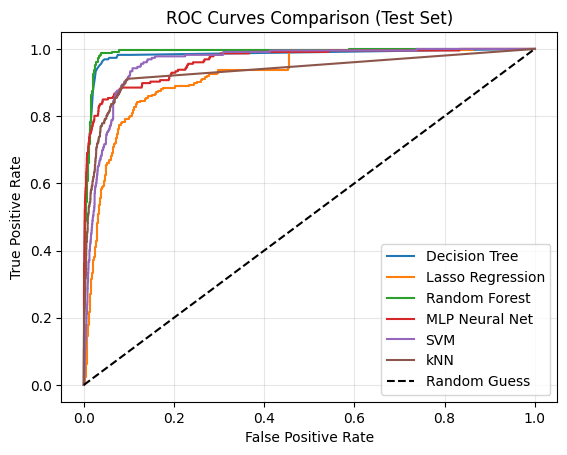

In [ ]:
# Calculate ROC curve points (FPR and TPR)
fpr_tree, tpr_tree, _ = roc_curve(y_test, probs_tree)
fpr_lr, tpr_lr, _ = roc_curve(y_test, probs_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, probs_rf)
fpr_mlp, tpr_mlp, _ = roc_curve(y_test, probs_mlp)
fpr_svm, tpr_svm, _ = roc_curve(y_test, probs_svm)
fpr_knn, tpr_knn, _ = roc_curve(y_test, probs_knn)

# Plot the ROC Curves
plt.plot(fpr_tree, tpr_tree, label=f'Decision Tree')
plt.plot(fpr_lr, tpr_lr, label=f'Lasso Regression')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest')
plt.plot(fpr_mlp, tpr_mlp, label=f'MLP Neural Net')
plt.plot(fpr_svm, tpr_svm, label=f'SVM')
plt.plot(fpr_knn, tpr_knn, label=f'kNN')

plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves Comparison (Test Set)')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)

plt.show()

In [ ]:
# Store the results in a dictionary for easy comparison
auc_results = {
    'Decision Tree': auc_tree,
    'Lasso Regression': auc_lr,
    'Random Forest': auc_rf,
    'MLP': auc_mlp,
    'SVM': auc_svm,
    'kNN': auc_knn
}

# Convert to a DataFrame for structured presentation
summary_df = pd.DataFrame(list(auc_results.items()), columns=['Model', 'Test AUC'])

# ort models by performance in descending order
summary_df = summary_df.sort_values(by='Test AUC', ascending=False).reset_index(drop=True)

# Display the comparison table
print("--- Model Performance Comparison ---")
print(summary_df)
print("-" * 36)

# Extract and print the best performing model and its AUC
best_model_name = summary_df.loc[0, 'Model']
max_auc_value = summary_df.loc[0, 'Test AUC']

print(f"The Best Performing Model is: {best_model_name}")
print(f"Maximum Test AUC Score: {max_auc_value:.4f}")

--- Model Performance Comparison ---
              Model  Test AUC
0     Random Forest  0.989189
1     Decision Tree  0.982124
2               MLP  0.963455
3               SVM  0.959763
4               kNN  0.934168
5  Lasso Regression  0.920294
------------------------------------
The Best Performing Model is: Random Forest
Maximum Test AUC Score: 0.9892


In [9]:
# Define the best_model
best_model = random_forest

# best_model = RandomForestClassifier(random_state = 42, max_depth = 10, min_samples_leaf = 70, n_estimators = 200, class_weight = 'balanced_subsample')
# best_model.fit(X_train, y_train)

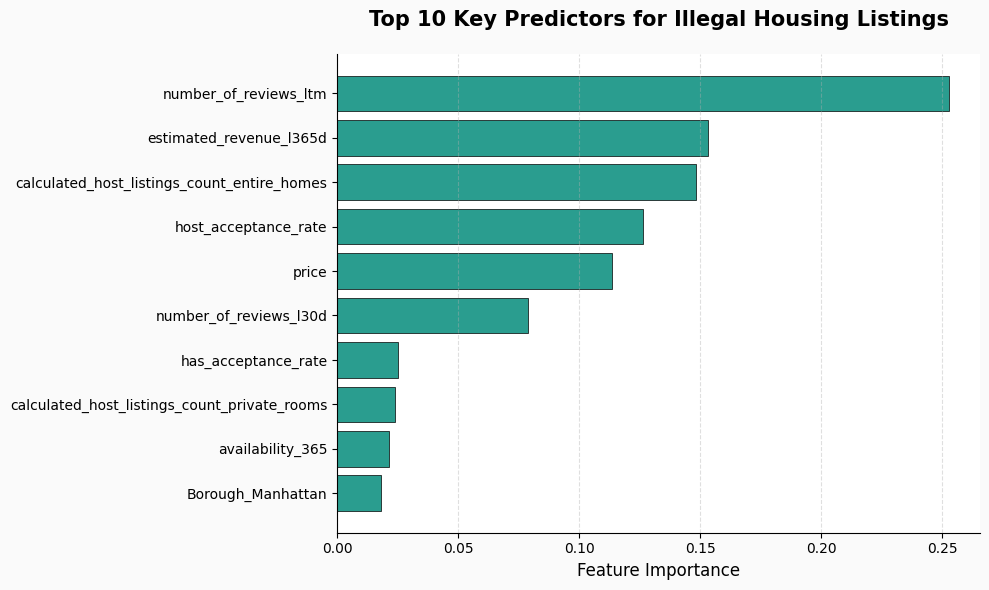

In [10]:
# --- Feature Importance Analysis: Identifying Key Risk Drivers ---

# Extracting the importance scores from our trained Random Forest model
importances = random_forest.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})

# Sorting to highlight the top 10 most influential features
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False).head(10)

# --- Visualization for Stakeholder Presentation ---
plt.figure(figsize=(10, 6), facecolor='#FAFAFA')

# Horizontal bar chart for better readability of feature names
plt.barh(feature_importance_df['Feature'][::-1],
         feature_importance_df['Importance'][::-1],
         color='#2A9D8F', edgecolor='black', linewidth=0.5)

# Adding clear titles and labels for business context
plt.title('Top 10 Key Predictors for Illegal Housing Listings', fontsize=15, fontweight='bold', pad=20)
plt.xlabel('Feature Importance', fontsize=12)

# Clean up visual elements (removing redundant spines)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.grid(axis='x', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

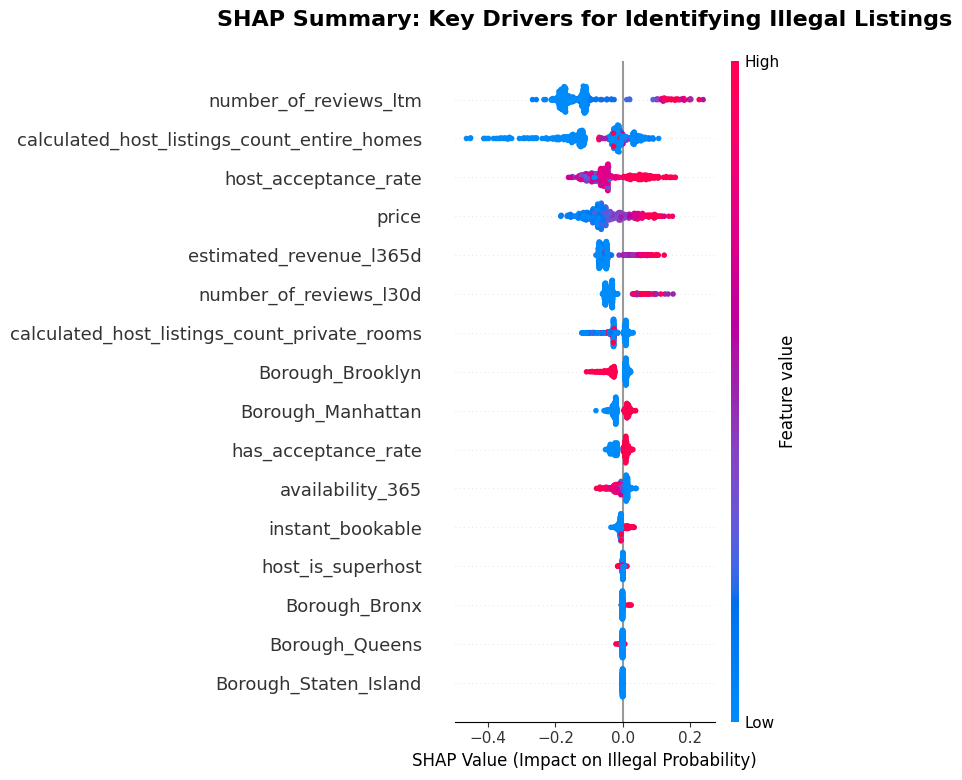

In [11]:
# --- SHAP Explainer: Deciphering the "Why" Behind Each Prediction ---
import shap

# 1. Create the explainer
explainer = shap.TreeExplainer(random_forest)

# --- 2. Prepare a clean sample for visualization ---
# Increase to 500-1000 samples for a "fuller" and more professional look
X_sample = X_test.iloc[:500]

# --- 3. Calculate SHAP values ---
# This returns a list: [values_for_class_0, values_for_class_1]
all_shap_values = explainer.shap_values(X_sample)

# --- 4. Handle Dimensions and Extract Class 1 (Illegal) ---
# We use .squeeze() to ensure we have a 2D matrix (samples x features)
if isinstance(all_shap_values, list):
    # Select index 1 for the 'Illegal' probability
    target_shap_values = np.array(all_shap_values[1]).squeeze()
else:
    target_shap_values = np.array(all_shap_values).squeeze()

# Fix for some SHAP versions that return a 3D array [samples, features, classes]
if len(target_shap_values.shape) == 3:
    target_shap_values = target_shap_values[:, :, 1]

# --- 5. Wrap into a SHAP Explanation Object ---
# This format is required for the modern beeswarm plot to show all features correctly
exp = shap.Explanation(
    values=target_shap_values,
    data=X_sample.values,
    feature_names=X_sample.columns.tolist()
)

# --- 6. Final Professional Visualization ---
# Setting a wide figsize (15) prevents horizontal crowding
plt.figure(figsize=(15, 10))

# max_display ensures all your features (up to 20) are shown on the y-axis
shap.plots.beeswarm(exp, max_display=20, show=False)

# Add professional titles and clean up the layout
plt.title("SHAP Summary: Key Drivers for Identifying Illegal Listings", fontsize=16, fontweight='bold', pad=25)
plt.xlabel("SHAP Value (Impact on Illegal Probability)", fontsize=12)

# Adjust layout to ensure no labels are cut off
plt.tight_layout()
plt.show()

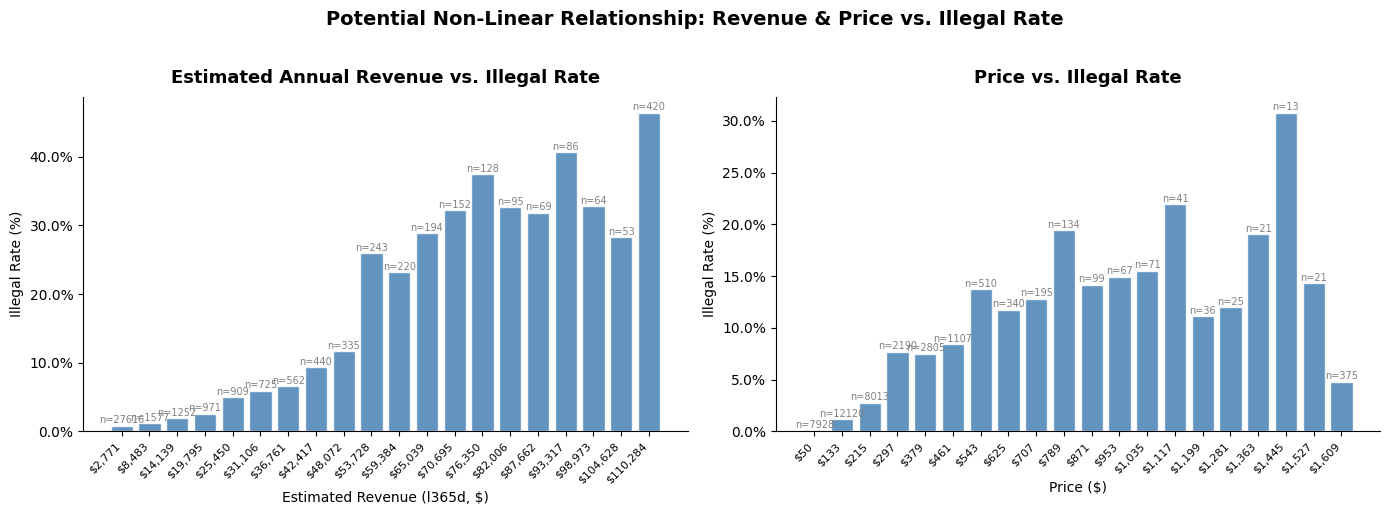

In [22]:
import matplotlib.patches as mpatches

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

features = ['estimated_revenue_l365d', 'price']
titles = ['Estimated Annual Revenue vs. Illegal Rate', 'Price vs. Illegal Rate']
xlabels = ['Estimated Revenue (l365d, $)', 'Price ($)']

for ax, feat, title, xlabel in zip(axes, features, titles, xlabels):
    # Use the full modeling dataframe (before train/test split)
    col = model_df[feat].copy()

    # Clip extreme outliers at 99th percentile for cleaner bins
    upper = col.quantile(0.99)
    col_clipped = col.clip(upper=upper)

    # Create 10 equal-width bins
    bins = pd.cut(col_clipped, bins=20)

    # Calculate illegal rate per bin
    bin_stats = model_df.groupby(bins, observed=True)['is_illegal'].agg(['mean', 'count']).reset_index()
    bin_stats.columns = ['bin', 'illegal_rate', 'count']
    bin_stats['bin_mid'] = bin_stats['bin'].apply(lambda x: x.mid)

    # Bar plot
    bars = ax.bar(
        range(len(bin_stats)),
        bin_stats['illegal_rate'] * 100,
        color='steelblue',
        edgecolor='white',
        alpha=0.85
    )

    # Overlay count as text
    for i, (rate, count) in enumerate(zip(bin_stats['illegal_rate'], bin_stats['count'])):
        ax.text(i, rate * 100 + 0.05, f'n={count}', ha='center', va='bottom', fontsize=7, color='gray')

    # X tick labels: bin midpoints
    ax.set_xticks(range(len(bin_stats)))
    ax.set_xticklabels(
        [f'${x.mid:,.0f}' for x in bin_stats['bin']],
        rotation=45, ha='right', fontsize=8
    )

    ax.set_title(title, fontsize=13, fontweight='bold', pad=10)
    ax.set_xlabel(xlabel, fontsize=10)
    ax.set_ylabel('Illegal Rate (%)', fontsize=10)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.1f}%'))

plt.suptitle('Potential Non-Linear Relationship: Revenue & Price vs. Illegal Rate',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

##Esemble Models

###Hard Voting

In [ ]:
# Get predicted probabilities for the TEST set from all six models
# These variables were already calculated in previous cells:
# probs_tree, probs_lr, probs_rf, probs_mlp, probs_svm, probs_knn

# Convert probabilities to binary predictions (0 or 1) using a 0.5 threshold
pred_tree = (probs_tree > 0.5).astype(int)
pred_lr = (probs_lr > 0.5).astype(int)
pred_rf = (probs_rf > 0.5).astype(int)
pred_mlp = (probs_mlp > 0.5).astype(int)
pred_svm = (probs_svm > 0.5).astype(int)
pred_knn = (probs_knn > 0.5).astype(int)

# Stack all binary predictions
all_predictions = np.column_stack([
    pred_tree,
    pred_lr,
    pred_rf,
    pred_mlp,
    pred_svm,
    pred_knn
])

# Apply the majority vote logic: if 3 or more models predict '1', the ensemble predicts '1'
ensemble_predictions = (np.sum(all_predictions, axis=1) >= 3).astype(int)

# Calculate the Test AUC for the ensemble
auc_ensemble = roc_auc_score(y_test, ensemble_predictions)

print(f"Test AUC - Ensemble (Majority Vote): {auc_ensemble:.4f}")

Test AUC - Ensemble (Majority Vote): 0.9524


In [ ]:
import itertools

# Map model names to their respective test probabilities
model_probs = {
    'Decision Tree': probs_tree,
    'Lasso Regression': probs_lr,
    'Random Forest': probs_rf,
    'MLP Neural Net': probs_mlp,
    'SVM': probs_svm,
    'kNN': probs_knn
}

model_names = list(model_probs.keys())

best_auc = -1
best_combination = None
best_threshold = None

results = []

print("Starting ensemble optimization across all model combinations...")

# Iterate through all possible sizes of model combinations (from 1 to 6)
for r in range(1, len(model_names) + 1):
    # Generate all combinations of models of size r
    for combo in itertools.combinations(model_names, r):
        current_combo_probs = []
        for model_name in combo:
            current_combo_probs.append((model_probs[model_name] > 0.5).astype(int))

        # Stack the predictions for the current combination
        current_combo_predictions = np.column_stack(current_combo_probs)

        # Iterate through possible majority vote thresholds for the current combination
        # A threshold of 1 means at least one model predicts 1, up to all models in the combo.
        for threshold in range(1, len(combo) + 1):
            ensemble_predictions = (np.sum(current_combo_predictions, axis=1) >= threshold).astype(int)

            # Ensure ensemble_predictions is not all 0s or all 1s, which can cause issues with roc_auc_score
            if len(np.unique(y_test)) < 2 or len(np.unique(ensemble_predictions)) < 2:
                current_auc = 0.0 # Cannot compute AUC if predictions are constant
            else:
                current_auc = roc_auc_score(y_test, ensemble_predictions)

            results.append({
                'Models': ', '.join(combo),
                'Count': len(combo),
                'Threshold': threshold,
                'Test AUC': current_auc
            })

            if current_auc > best_auc:
                best_auc = current_auc
                best_combination = combo
                best_threshold = threshold

print("Optimization complete.\n")

results_df = pd.DataFrame(results).sort_values(by='Test AUC', ascending=False)

print("Top 5 Ensemble Combinations by Test AUC (Hard Voting):")
display(results_df.head())

print(f"\nOverall Best Ensemble:")
print(f"  Models: {', '.join(best_combination)}")
print(f"  Number of Models: {len(best_combination)}")
print(f"  Majority Vote Threshold: {best_threshold}")
print(f"  Achieved Test AUC: {best_auc:.4f}")

Starting ensemble optimization across all model combinations...
Optimization complete.

Top 5 Ensemble Combinations by Test AUC:


,Models,Count,Threshold,Test AUC
2,Random Forest,1,1,0.972785
24,"Random Forest, MLP Neural Net",2,1,0.971925
26,"Random Forest, SVM",2,1,0.971285
28,"Random Forest, kNN",2,1,0.971142
87,"Random Forest, MLP Neural Net, kNN",3,1,0.970853



Overall Best Ensemble:
  Models: Random Forest
  Number of Models: 1
  Majority Vote Threshold: 1
  Achieved Test AUC: 0.9728


###Soft Voting

In [ ]:
# To get a more nuanced AUC, we can average the probabilities directly or create a weighted average
# Here, we'll also show AUC for averaged probabilities, which often performs better than hard voting.
# (This is conceptually closer to soft voting if models were calibrated)
ensemble_probs_avg = np.mean(np.column_stack([
    probs_tree,
    probs_lr,
    probs_rf,
    probs_mlp,
    probs_svm,
    probs_knn
]), axis=1)

auc_ensemble_avg_probs = roc_auc_score(y_test, ensemble_probs_avg)
print(f"Test AUC - Ensemble (Averaged Probabilities): {auc_ensemble_avg_probs:.4f}")

Test AUC - Ensemble (Averaged Probabilities): 0.9883


In [ ]:
# Map model names to their respective test probabilities
model_probs = {
    'Decision Tree': probs_tree,
    'Lasso Regression': probs_lr,
    'Random Forest': probs_rf,
    'MLP Neural Net': probs_mlp,
    'SVM': probs_svm,
    'kNN': probs_knn
}

model_names = list(model_probs.keys())

best_auc = -1
best_combination = None
best_soft_vote_approach = None # To clarify it's soft voting

results = []

print("Starting soft voting ensemble optimization across all model combinations (averaging probabilities)...")

# Iterate through all possible sizes of model combinations (from 1 to 6)
for r in range(1, len(model_names) + 1):
    # Generate all combinations of models of size r
    for combo in itertools.combinations(model_names, r):
        current_combo_raw_probs = []
        for model_name in combo:
            # Collect raw probabilities for soft voting
            current_combo_raw_probs.append(model_probs[model_name])

        # Stack the raw probabilities for the current combination
        stacked_raw_probs = np.column_stack(current_combo_raw_probs)

        # Calculate the mean of these raw probabilities for soft voting
        ensemble_soft_probs = np.mean(stacked_raw_probs, axis=1)

        # Calculate AUC for the soft voting ensemble
        # Ensure y_test and ensemble_soft_probs are not constant
        if len(np.unique(y_test)) < 2 or len(np.unique(ensemble_soft_probs)) < 2:
            current_auc = 0.0 # Cannot compute AUC if predictions are constant
        else:
            current_auc = roc_auc_score(y_test, ensemble_soft_probs)

        results.append({
            'Models': ', '.join(combo),
            'Count': len(combo),
            'Threshold': 'Mean Prob', # Indicates this is mean probability, not a hard vote threshold
            'Test AUC': current_auc
        })

        if current_auc > best_auc:
            best_auc = current_auc
            best_combination = combo
            best_soft_vote_approach = 'Mean Prob'

print("Optimization complete.\n")

results_df = pd.DataFrame(results).sort_values(by='Test AUC', ascending=False)

print("Top 15 Ensemble Combinations by Test AUC (Soft Voting):") # Modified title
display(results_df.head(15))

print(f"\nOverall Best Ensemble (Soft Voting):") # Modified title
print(f"  Models: {', '.join(best_combination)}")
print(f"  Number of Models: {len(best_combination)}")
print(f"  Soft Vote Approach: {best_soft_vote_approach}") # Modified label
print(f"  Achieved Test AUC: {best_auc:.4f}")

Starting soft voting ensemble optimization across all model combinations (averaging probabilities)...
Optimization complete.

Top 15 Ensemble Combinations by Test AUC (Soft Voting):


,Models,Count,Threshold,Test AUC
25,"Decision Tree, Random Forest, MLP Neural Net",3,Mean Prob,0.990826
48,"Decision Tree, Random Forest, MLP Neural Net, kNN",4,Mean Prob,0.990598
27,"Decision Tree, Random Forest, kNN",3,Mean Prob,0.990243
47,"Decision Tree, Random Forest, MLP Neural Net, SVM",4,Mean Prob,0.990206
60,"Decision Tree, Random Forest, MLP Neural Net, ...",5,Mean Prob,0.990178
15,"Random Forest, MLP Neural Net",2,Mean Prob,0.990082
17,"Random Forest, kNN",2,Mean Prob,0.989876
49,"Decision Tree, Random Forest, SVM, kNN",4,Mean Prob,0.989829
7,"Decision Tree, Random Forest",2,Mean Prob,0.989685
38,"Random Forest, MLP Neural Net, kNN",3,Mean Prob,0.989576



Overall Best Ensemble (Soft Voting):
  Models: Decision Tree, Random Forest, MLP Neural Net
  Number of Models: 3
  Soft Vote Approach: Mean Prob
  Achieved Test AUC: 0.9908


We can see that the combinition of **Decision Tree, Random Forest and MLP Neural Net** is the best model compared to the random forest itself.

However we'll still use random forest as our best model as it's much more easier and not much worse than the greatest esembled model.

##Profit Analysis

###Cost/Benefit Matrix

**Business Context & Assumptions**

The NYC OSE operates with limited manpower and budget; therefore, they cannot manually audit all 36,000+ Airbnb listings.

Our goal is to use a **Cost-Benefit Matrix** to identify the optimal percentage of high-risk listings the OSE should audit to maximize their net revenue. Since we do not have official internal accounting data from the OSE, we base our profit matrix on the following realistic estimates derived from NYC Local Law 18 and standard municipal inspection costs:

* **Benefit (True Positive - Catching an illegal host):** According to LL18, fines for illegal short-term rentals can range from \$100 to \$5,000. We conservatively estimate the average fine collected per successfully verified illegal listing to be **\$2,500**.
* **Cost (False Positive - Auditing a compliant host):** Based on standard NYC building and safety inspection fees, we estimate the cost of a single field audit to be **\$300**.
* **True Negative / False Negative:** We assign a cost/benefit of **$0**, assuming no immediate financial transaction occurs if no action is taken.

By applying this matrix to our model's predicted probabilities, we will generate a Profit Curve to determine the precise probability threshold that maximizes financial return for the city.

In [ ]:
# Based on NYC Local Law 18 and standard inspection costs
fine_revenue = 2500.0   # Revenue per successful audit (TP)
inspection_cost = 300.0 # Cost per inspection (FP)

b_tp = fine_revenue - inspection_cost
b_fp = -inspection_cost
b_fn = 0
b_tn = 0

In [ ]:
cb_matrix_data = [
    [f"B(TP): ${b_tp:.2f}", f"B(FP): ${b_fp:.2f}"],
    [f"B(FN): ${b_fn:.2f}", f"B(TN): ${b_tn:.2f}"]
]

cost_benefit_df = pd.DataFrame(
    cb_matrix_data,
    index=['Pred = 1', 'Pred = 0'],
    columns=['Truth = 1', 'Truth = 0']
)

print("Cost / Benefit Matrix (Per Audit Value):")
display(cost_benefit_df)

Cost / Benefit Matrix (Per Audit Value):


,Truth = 1,Truth = 0
Pred = 1,B(TP): $2200.00,B(FP): $-300.00
Pred = 0,B(FN): $0.00,B(TN): $0.00


### Generating the Final Deployment Table using Out-of-Fold Predictions

While our initial evaluation was conducted on a 20% hold-out test set, the ultimate business objective for the NYC OSE is to score the **entire dataset (36,000+ listings)** to generate a comprehensive audit priority list.

However, simply applying our trained model to the entire dataset would introduce **Data Leakage**, as the model would artificially output higher confidence scores for the 80% of data it has already "seen" during training.

To solve this, we generate **Out-of-Fold (OOF) predictions** using 5-Fold Cross-Validation. This ensures that every single listing in the 36,000+ dataset receives an unbiased predicted probability (`prob_illegal`) from a model that was *not* trained on that specific listing. Finally, we apply our business logic: filtering out the obvious heuristic violations (`actual_label = 1`) to deliver a pure list of high-risk "shadow" listings for the inspectors.

In [ ]:
from sklearn.model_selection import cross_val_predict

# --- 1. Generate Out-of-Fold (OOF) Probabilities for 100% of the data ---
# This uses 5-fold CV to ensure no data leakage.
# X and y should be your FULL dataset before the train_test_split.
print("Generating Out-of-Fold predictions for the entire dataset... (This might take a minute)")
oof_probs = cross_val_predict(best_model, X, y, cv=5, method='predict_proba')[:, 1]

# --- 2. Create the Full Results Table ---
# Combine IDs, Actual Labels, and the new unbiased probabilities
full_results_df = pd.DataFrame({
    'id': model_df['id'],           # Assuming model_df is your original dataframe
    'host_id': model_df['host_id'],
    'actual_label': y,
    'prob_illegal': oof_probs
})

# --- 3. Apply Business Logic: Filter out obvious '1's ---
# We only want to inspect surface-compliant listings (Label = 0)
final_audit_list = full_results_df[full_results_df['actual_label'] == 0].copy()

# --- 4. Rank Ordering by Risk ---
# Sort descending so the most suspicious listings are at the top
final_audit_list = final_audit_list.sort_values(by='prob_illegal', ascending=False).reset_index(drop=True)

print(f"Total 'Surface-Compliant' listings ready for audit scoring: {len(final_audit_list)}")
print("-" * 50)
print("Top 10 Highest-Risk Listings for OSE Deployment:")

# Display the final table
display(final_audit_list.head(10))

Generating Out-of-Fold predictions for the entire dataset... (This might take a minute)
Total 'Surface-Compliant' listings ready for audit scoring: 35031
--------------------------------------------------
Top 10 Highest-Risk Listings for OSE Deployment:


,id,host_id,actual_label,prob_illegal
0,980616234786854392,537135281,0,0.993943
1,35914632,269987340,0,0.989622
2,1302785704600506643,471177409,0,0.989468
3,431865,361855,0,0.989345
4,35038426,211549023,0,0.989302
5,1038615845898550577,75266494,0,0.989092
6,1021738415510509168,183787653,0,0.989000
7,30398938,211549023,0,0.988746
8,1034113003712981730,75266494,0,0.988662
9,4936254,22087408,0,0.987341


In [ ]:
final_audit_list.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35031 entries, 0 to 35030
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id            35031 non-null  int64  
 1   host_id       35031 non-null  int64  
 2   actual_label  35031 non-null  int64  
 3   prob_illegal  35031 non-null  float64
dtypes: float64(1), int64(3)
memory usage: 1.1 MB


### "True Illegal" via Monte Carlo Simulation (Full Dataset)

In a real-world scenario, the `is_illegal` labels derived from our heuristic rules are merely proxies. To estimate the actual financial return (ROI) of deploying our model across New York City, we must account for the uncertainty of audit outcomes on the seemingly compliant listings.

We perform a **Monte Carlo Simulation** by treating the model's Out-of-Fold predicted probability (`prob_illegal`) as the true likelihood of a listing being illegal. For each listing in our `final_audit_list` (surface-compliant listings), we simulate a "Field Audit" outcome:
* If a listing has a probability of $n$, it has an $n$ chance of being assigned a simulated status of **1 (Verified Illegal)**, and a $(1-n)$ chance of being assigned a simulated status of **0 (Verified Legal)**.

By sorting these listings by their risk scores and calculating the cumulative profit based on these simulated outcomes, we can determine the optimal audit capacity for the NYC OSE.

In [ ]:
# --- 1. Monte Carlo Simulation for "True" Outcomes ---
np.random.seed(42) # Set seed for reproducibility

# Simulate "Field Audit":
# Generate a random float [0.0, 1.0) for each row.
# If it's less than 'prob_illegal', it simulates catching an illegal listing (1).
final_audit_list['true_illegal'] = (np.random.rand(len(final_audit_list)) < final_audit_list['prob_illegal']).astype(int)

In [ ]:
final_audit_list.head(3)

,id,host_id,actual_label,prob_illegal,true_illegal
0,980616234786854392,537135281,0,0.993943,1
1,35914632,269987340,0,0.989622,1
2,1302785704600506643,471177409,0,0.989468,1


In [ ]:
# --- 2. Calculate Marginal and Cumulative Profit ---
# Apply the financial assumptions directly to the simulated reality
final_audit_list['marginal_profit'] = np.where(final_audit_list['true_illegal'] == 1, b_tp, b_fp)

# Calculate cumulative profit as inspectors work down the list
final_audit_list['cumulative_profit'] = final_audit_list['marginal_profit'].cumsum()

# Calculate the X-axis: Percentage of listings audited
final_audit_list['percent_audited'] = (np.arange(1, len(final_audit_list) + 1) / len(final_audit_list)) * 100

In [ ]:
final_audit_list.head(3)

,id,host_id,actual_label,prob_illegal,true_illegal,marginal_profit,cumulative_profit,percent_audited
0,980616234786854392,537135281,0,0.993943,1,2200.0,2200.0,0.002855
1,35914632,269987340,0,0.989622,1,2200.0,4400.0,0.005709
2,1302785704600506643,471177409,0,0.989468,1,2200.0,6600.0,0.008564


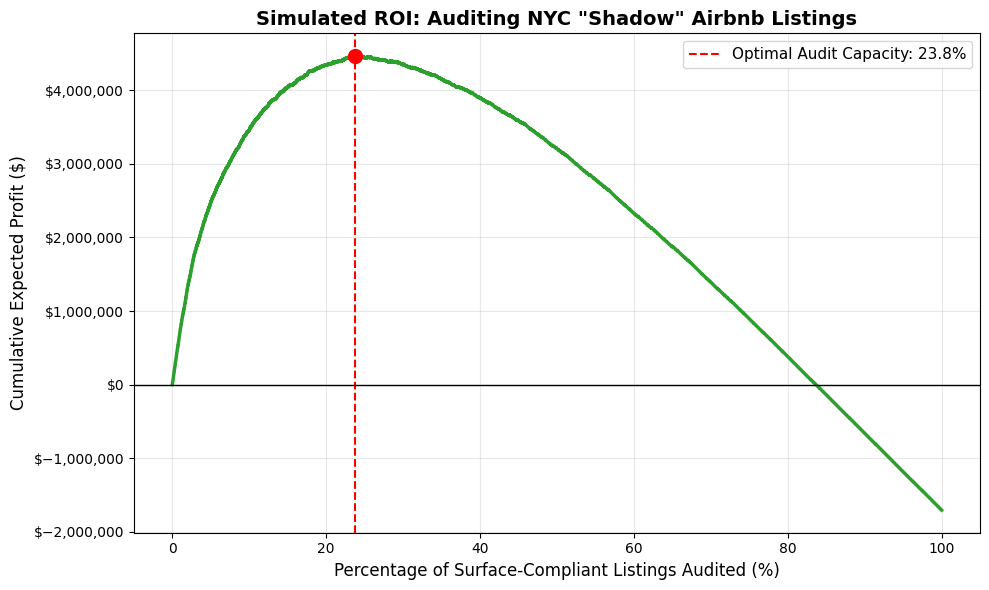

In [ ]:
import matplotlib.ticker as ticker

# --- 3. Plot the Profit Curve ---
plt.figure(figsize=(10, 6))
plt.plot(final_audit_list['percent_audited'], final_audit_list['cumulative_profit'], color='#2ca02c', linewidth=2.5)

# Identify the point of maximum cumulative profit
max_profit_idx = final_audit_list['cumulative_profit'].idxmax()
max_profit = final_audit_list.loc[max_profit_idx, 'cumulative_profit']
best_percent = final_audit_list.loc[max_profit_idx, 'percent_audited']

# Add optimal cutoff markers
plt.axvline(x=best_percent, color='red', linestyle='--', label=f'Optimal Audit Capacity: {best_percent:.1f}%')
plt.scatter(best_percent, max_profit, color='red', s=100, zorder=5)

# Add a baseline for breaking even ($0 profit)
plt.axhline(y=0, color='black', linestyle='-', linewidth=1)

# Formatting the plot
plt.title('Simulated ROI: Auditing NYC "Shadow" Airbnb Listings', fontsize=14, fontweight='bold')
plt.xlabel('Percentage of Surface-Compliant Listings Audited (%)', fontsize=12)
plt.ylabel('Cumulative Expected Profit ($)', fontsize=12)

# Format the Y-axis as dollars
formatter = ticker.StrMethodFormatter('${x:,.0f}')
plt.gca().yaxis.set_major_formatter(formatter)

plt.grid(alpha=0.3)
plt.legend(fontsize=11)
plt.tight_layout()

plt.show()

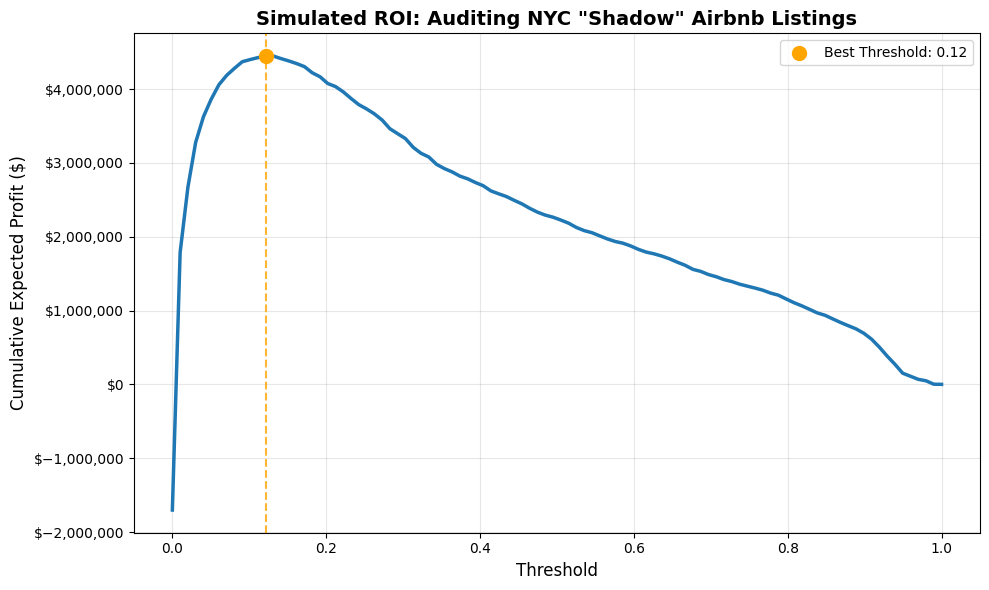

In [ ]:
# --- 3.5 Plot Profit vs. Threshold ---
# Create a range of thresholds from 0 to 1
threshold_range = np.linspace(0, 1, 100)
threshold_profits = []

# Calculate profit for each potential threshold
for t in threshold_range:
    # Simulating the policy: "Only audit if prob_illegal >= t"
    potential_audits = final_audit_list[final_audit_list['prob_illegal'] >= t]
    t_profit = potential_audits['marginal_profit'].sum() if not potential_audits.empty else 0
    threshold_profits.append(t_profit)

plt.figure(figsize=(10, 6))
plt.plot(threshold_range, threshold_profits, color='#1f77b4', linewidth=2.5)

# Locate the optimal threshold for the annotation
opt_threshold = threshold_range[np.argmax(threshold_profits)]
max_p_value = max(threshold_profits)

# Add marker for the optimal threshold
plt.axvline(x=opt_threshold, color='orange', linestyle='--', alpha=0.8)
plt.scatter(opt_threshold, max_p_value, color='orange', s=100, label=f'Best Threshold: {opt_threshold:.2f}', zorder=5)

# Aesthetics
plt.title('Simulated ROI: Auditing NYC "Shadow" Airbnb Listings', fontsize=14, fontweight='bold')
plt.xlabel('Threshold', fontsize=12)
plt.ylabel('Cumulative Expected Profit ($)', fontsize=12)
plt.gca().yaxis.set_major_formatter(ticker.StrMethodFormatter('${x:,.0f}'))
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

plt.show()

In [ ]:
# Build the Confusion Matrix
y_pred_binary = (final_audit_list['prob_illegal'] >= opt_threshold).astype(int)
y_true_simulated = final_audit_list['true_illegal']

TP = ((y_pred_binary == 1) & (y_true_simulated == 1)).sum()
FP = ((y_pred_binary == 1) & (y_true_simulated == 0)).sum()
FN = ((y_pred_binary == 0) & (y_true_simulated == 1)).sum()
TN = ((y_pred_binary == 0) & (y_true_simulated == 0)).sum()

precision = TP / (TP + FP) if (TP + FP) > 0 else 0
recall    = TP / (TP + FN) if (TP + FN) > 0 else 0
f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

cm_data = [
    [f"TP: {TP:,}", f"FP: {FP:,}"],
    [f"FN: {FN:,}", f"TN: {TN:,}"]
]

cm_df = pd.DataFrame(
    cm_data,
    index=['Pred = Illegal', 'Pred = Compliant'],
    columns=['Truth = Illegal', 'Truth = Compliant']
)

print(f"Confusion Matrix at Optimal Threshold ({opt_threshold:.2f}):")
display(cm_df)
print(f"\nPrecision : {precision:.2%}  (of all audited listings, this % were truly illegal)")
print(f"Recall    : {recall:.2%}  (of all truly illegal listings, this % were caught)")
print(f"F1 Score  : {f1:.2%}")

Confusion Matrix at Optimal Threshold (0.12):


,Truth = Illegal,Truth = Compliant
Pred = Illegal,"TP: 2,820","FP: 5,858"
Pred = Compliant,FN: 703,"TN: 25,650"



Precision : 32.50%  (of all audited listings, this % were truly illegal)
Recall    : 80.05%  (of all truly illegal listings, this % were caught)
F1 Score  : 46.23%


In [ ]:
# --- 4. Print the Final Business Strategy ---
total_shadow_listings = len(final_audit_list)
recommended_audit_count = int((best_percent / 100) * total_shadow_listings)

optimal_threshold = final_audit_list.loc[max_profit_idx, 'prob_illegal']

print("=" * 75)
print("🎯 FINAL BUSINESS DEPLOYMENT RECOMMENDATION 🎯")
print("=" * 75)
print(f"Total target pool: {total_shadow_listings:,} surface-compliant listings.")
print(f"To maximize ROI, the OSE should audit the top {best_percent:.1f}% highest-risk listings.")
print(f"This equates to dispatching inspectors to exactly {recommended_audit_count:,} listings.")
print(f"Probability Threshold: Only audit listings with a risk score >= {optimal_threshold:.4f}")
print(f"Expected Maximum Net Profit for the City: ${max_profit:,.2f}")
print("=" * 75)

🎯 FINAL BUSINESS DEPLOYMENT RECOMMENDATION 🎯
Total target pool: 35,031 surface-compliant listings.
To maximize ROI, the OSE should audit the top 23.8% highest-risk listings.
This equates to dispatching inspectors to exactly 8,327 listings.
Probability Threshold: Only audit listings with a risk score >= 0.1287
Expected Maximum Net Profit for the City: $4,464,400.00


###Probability Calibration

**The "Shadow Listing" Gap**

In most data science projects, a curve deviating from the diagonal indicates a flawed or "over-confident" model. However, in our NYC Airbnb Enforcement context, this gap represents the Discovery Potential. The original historical labels only show who was already caught; the model's apparent "over-confidence" is actually the AI identifying Shadow Listings—illegal operations that have successfully evaded manual inspection until now.

**Validation against Refined Reality (`true_illegal`)**

To prove our financial projections are robust, we validate the model scores against our Simulated "True" Outcomes. This "Hybrid Reality" allows us to test the model's performance in a more realistic environment that includes:

*   Confirmed Violations: Historically flagged illegal listings (the "known" truths).
*   Shadow Discoveries: Latent violations identified by the model’s risk scores but previously hidden from official OSE records.



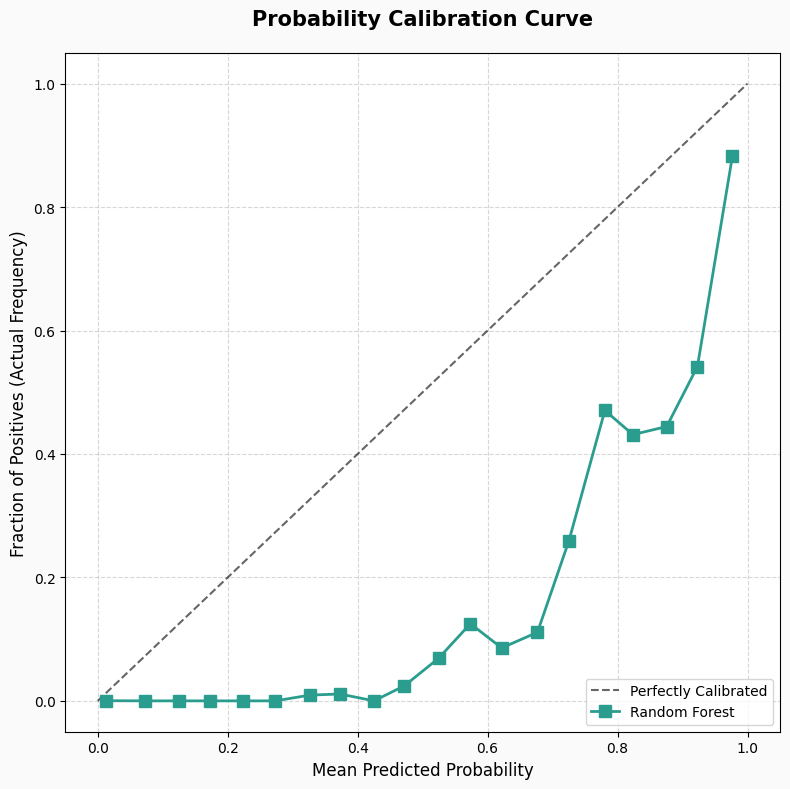

In [ ]:
from sklearn.calibration import calibration_curve

# --- 1. Calculate Calibration Curve Data ---
# prob_pos: The predicted probabilities for the positive class (Illegal)
# n_bins: Divide the 0-1 range into 10 bins (0.1, 0.2, etc.)
prob_pos = random_forest.predict_proba(X_test)[:, 1]
fraction_of_positives, mean_predicted_value = calibration_curve(y_test, prob_pos, n_bins=20)

# --- 2. Professional Visualization ---
plt.figure(figsize=(8, 8), facecolor='#FAFAFA')

# The "Perfectly Calibrated" diagonal line
plt.plot([0, 1], [0, 1], "k--", label="Perfectly Calibrated", alpha=0.6)

# Our model's curve
plt.plot(mean_predicted_value, fraction_of_positives, "s-", color='#2A9D8F',
         label="Random Forest", markersize=8, linewidth=2)

# Aesthetic adjustments
plt.title('Probability Calibration Curve', fontsize=15, fontweight='bold', pad=20)
plt.xlabel('Mean Predicted Probability', fontsize=12)
plt.ylabel('Fraction of Positives (Actual Frequency)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc="lower right", fontsize=10)
plt.tight_layout()

plt.show()

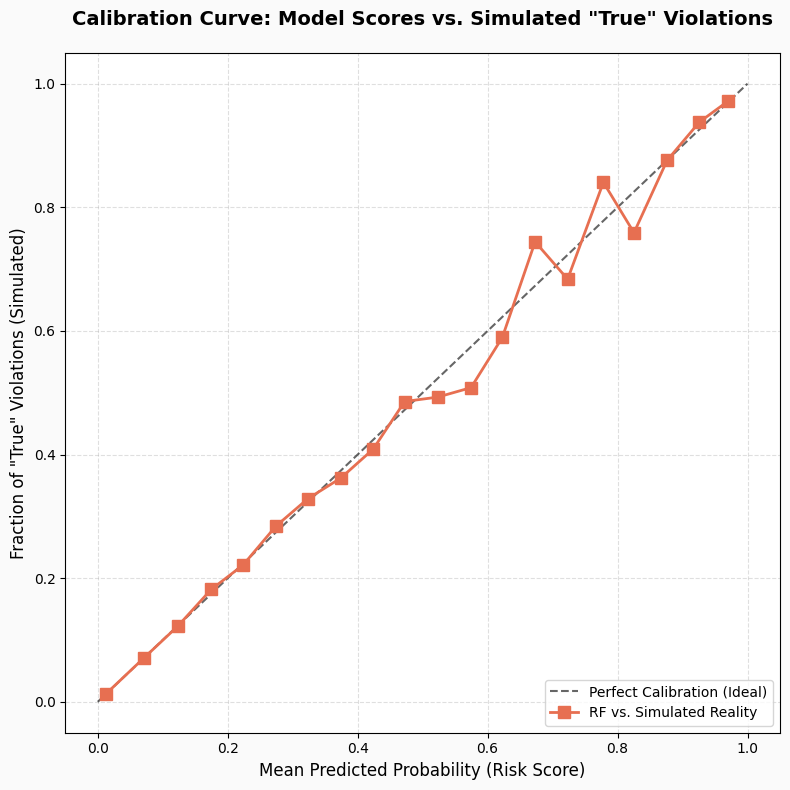

In [ ]:
# Get the probabilities and the "true" outcomes from your MCS list
y_simulated_true = final_audit_list['true_illegal']
probs_predicted = final_audit_list['prob_illegal']

# Calculate calibration curve data
# This will show how well our risk scores align with our "Discovery-inclusive" reality
fraction_of_positives, mean_predicted_value = calibration_curve(
    y_simulated_true,
    probs_predicted,
    n_bins=20
)

# Visualization
plt.figure(figsize=(8, 8), facecolor='#FAFAFA')

# Perfect calibration reference
plt.plot([0, 1], [0, 1], "k--", label="Perfect Calibration (Ideal)", alpha=0.6)

# Our model's curve based on the refined "True Illegal" labels
plt.plot(mean_predicted_value, fraction_of_positives, "s-", color='#E76F51',
         label="RF vs. Simulated Reality", markersize=8, linewidth=2)

# Professional formatting
plt.title('Calibration Curve: Model Scores vs. Simulated "True" Violations', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Mean Predicted Probability (Risk Score)', fontsize=12)
plt.ylabel('Fraction of "True" Violations (Simulated)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend(loc="lower right")

plt.tight_layout()
plt.show()

### Capacity-Constrained ROI: Model-Driven vs. Random Auditing

In a real-world operational setting, municipal agencies like the NYC OSE rarely have the flexibility to audit until theoretical profit peaks. Instead, they are strictly constrained by annual budgets and inspector headcount (capacity constraints).

To demonstrate the tangible operational value of our model, let us assume the OSE has the budget to conduct exactly **1,000 field audits** this quarter.

We will compare two strategies:
1.  **Random Auditing (Baseline):** The scenario without machine learning, where inspectors randomly select 1,000 surface-compliant listings to audit.
2.  **Model-Driven Auditing:** Our proposed strategy, where inspectors target the exact Top 1,000 highest-risk listings identified by our Out-of-Fold model probabilities.

By comparing the net financial outcome of these two approaches, we can isolate the direct "Lift" generated simply by integrating our predictive model into their existing workflow.

We can also change the audit capacity to reproduce the results.

In [ ]:
# --- 1. Define Capacity Constraint ---
audit_capacity = 1000

# Ensure we have enough data (fallback just in case)
audit_capacity = min(audit_capacity, len(final_audit_list))

# --- 2. Strategy A: Model-Driven Auditing (Top 1000) ---
# Since final_audit_list is already sorted by prob_illegal descending
model_driven_sample = final_audit_list.head(audit_capacity)
model_profit = model_driven_sample['marginal_profit'].sum()
model_caught = model_driven_sample['true_illegal'].sum()

# --- 3. Strategy B: Random Auditing (Baseline) ---
# Randomly sample 1000 listings from the entire surface-compliant pool
random_sample = final_audit_list.sample(n=audit_capacity, random_state=42)
random_profit = random_sample['marginal_profit'].sum()
random_caught = random_sample['true_illegal'].sum()

In [ ]:
# --- 4. Print the Comparison Results ---
print("=" * 60)
print(f"SCENARIO: BUDGET LIMITED TO {audit_capacity:,} AUDITS")
print("=" * 60)

print(f"STRATEGY A: Random Auditing (Without Model)")
print(f"  - Violations Caught: {random_caught:,}")
print(f"  - Net Profit/Loss:   ${random_profit:,.2f}")
print("-" * 60)

print(f"STRATEGY B: Model-Driven Auditing (With Model)")
print(f"  - Violations Caught: {model_caught:,}")
print(f"  - Net Profit/Loss:   ${model_profit:,.2f}")
print("-" * 60)

profit_lift = model_profit - random_profit
print(f"💡 INCREMENTAL VALUE ADDED BY MODEL: +${profit_lift:,.2f}")
print("=" * 60)

SCENARIO: BUDGET LIMITED TO 1,000 AUDITS
STRATEGY A: Random Auditing (Without Model)
  - Violations Caught: 91
  - Net Profit/Loss:   $-72,500.00
------------------------------------------------------------
STRATEGY B: Model-Driven Auditing (With Model)
  - Violations Caught: 828
  - Net Profit/Loss:   $1,770,000.00
------------------------------------------------------------
💡 INCREMENTAL VALUE ADDED BY MODEL: +$1,842,500.00


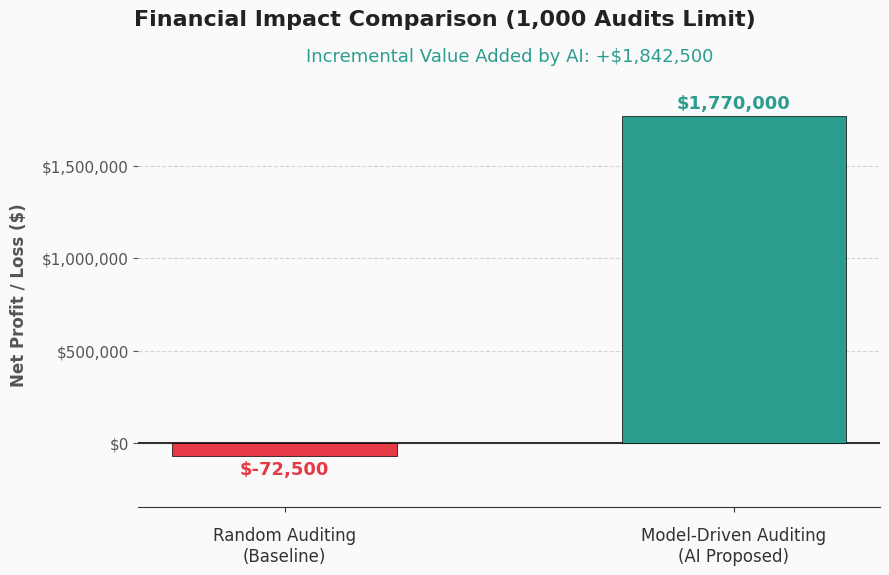

In [ ]:
# --- 5. Visualizing the Comparison (Consulting-Style Aesthetic) ---
strategies = ['Random Auditing\n(Baseline)', 'Model-Driven Auditing\n(AI Proposed)']
profits = [random_profit, model_profit]

# Premium color palette: Coral Red for loss, Emerald Green for profit
colors = ['#E63946' if p < 0 else '#2A9D8F' for p in profits]

# Set up the figure dimensions and background color
fig, ax = plt.subplots(figsize=(9, 6), facecolor='#FAFAFA')
ax.set_facecolor('#FAFAFA')

# Draw the bar chart, setting zorder to place bars above the grid lines
bars = ax.bar(strategies, profits, color=colors, width=0.5, edgecolor='black', linewidth=0.5, zorder=3)

min_y = min(profits)
max_y = max(profits)
y_range = max_y - min_y

ax.set_ylim(min_y - 0.15 * y_range, max_y + 0.10 * y_range)

# Highlight the breakeven line ($0) to clearly separate profit and loss
ax.axhline(0, color='#333333', linewidth=1.5, zorder=2)

# Format the Y-axis to display currency values clearly
formatter = ticker.StrMethodFormatter('${x:,.0f}')
ax.yaxis.set_major_formatter(formatter)
ax.tick_params(axis='y', labelsize=11, colors='#555555')
ax.tick_params(axis='x', labelsize=12, pad=10, colors='#333333')

# Optimize grid lines: Keep only horizontal lines and make them subtle
ax.grid(axis='y', linestyle='--', alpha=0.5, zorder=0)
ax.grid(axis='x', visible=False)

# Remove unnecessary spines (top, right, left) for a cleaner, modern look
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_color('#333333')

# Elegantly add data labels directly onto the bars
for bar, color in zip(bars, colors):
    yval = bar.get_height()

    # Adjust vertical offset based on whether profit is positive or negative
    offset = 20000 if yval >= 0 else -20000
    va = 'bottom' if yval >= 0 else 'top'

    # Add text labels with a semi-transparent background to prevent grid interference
    ax.text(bar.get_x() + bar.get_width()/2, yval + offset,
             f"${yval:,.0f}", ha='center', va=va,
             fontsize=13, fontweight='bold', color=color,
             bbox=dict(facecolor='#FAFAFA', edgecolor='none', alpha=0.9, pad=1))

# Add hierarchical titles (Main title and Subtitle) for maximum impact
plt.suptitle(f'Financial Impact Comparison ({audit_capacity:,} Audits Limit)',
             fontsize=16, fontweight='bold', color='#222222', y=0.98)

# Emphasize the "Incremental Value Added" directly in the subtitle for business stakeholders
profit_lift = model_profit - random_profit
plt.title(f'Incremental Value Added by AI: +${profit_lift:,.0f}',
          fontsize=13, fontweight='medium', color='#2A9D8F', pad=15)

# Format the Y-axis label
plt.ylabel('Net Profit / Loss ($)', fontsize=12, fontweight='bold', color='#555555', labelpad=10)

plt.tight_layout()
plt.subplots_adjust(bottom=0.15)
plt.show()

In [ ]:
# Build the Confusion Matrix at the capacity constraint (Top 1,000 audits)
top_capacity = final_audit_list.head(audit_capacity)
random_sample = final_audit_list.sample(n=audit_capacity, random_state=42)

# --- Model-Driven ---
TP_m = (top_capacity['true_illegal'] == 1).sum()
FP_m = (top_capacity['true_illegal'] == 0).sum()
FN_m = (final_audit_list.iloc[audit_capacity:]['true_illegal'] == 1).sum()
TN_m = (final_audit_list.iloc[audit_capacity:]['true_illegal'] == 0).sum()

precision_m = TP_m / (TP_m + FP_m) if (TP_m + FP_m) > 0 else 0
recall_m    = TP_m / (TP_m + FN_m) if (TP_m + FN_m) > 0 else 0
f1_m        = 2 * precision_m * recall_m / (precision_m + recall_m) if (precision_m + recall_m) > 0 else 0

# --- Random ---
TP_r = (random_sample['true_illegal'] == 1).sum()
FP_r = (random_sample['true_illegal'] == 0).sum()
FN_r = final_audit_list['true_illegal'].sum() - TP_r
TN_r = len(final_audit_list) - audit_capacity - FN_r

precision_r = TP_r / (TP_r + FP_r) if (TP_r + FP_r) > 0 else 0
recall_r    = TP_r / (TP_r + FN_r) if (TP_r + FN_r) > 0 else 0
f1_r        = 2 * precision_r * recall_r / (precision_r + recall_r) if (precision_r + recall_r) > 0 else 0

cm_model_data  = [
    [f"TP: {TP_m:,}", f"FP: {FP_m:,}"],
    [f"FN: {FN_m:,}", f"TN: {TN_m:,}"]
]
cm_random_data = [
    [f"TP: {TP_r:,}", f"FP: {FP_r:,}"],
    [f"FN: {FN_r:,}", f"TN: {TN_r:,}"]
]

cm_model_df  = pd.DataFrame(cm_model_data,  index=['Pred = Illegal', 'Pred = Compliant'], columns=['Truth = Illegal', 'Truth = Compliant'])
cm_random_df = pd.DataFrame(cm_random_data, index=['Pred = Illegal', 'Pred = Compliant'], columns=['Truth = Illegal', 'Truth = Compliant'])

print(f"Confusion Matrix — Strategy A: Random Auditing ({audit_capacity:,} audits)")
display(cm_random_df)
print(f"  Precision: {precision_r:.2%}   Recall: {recall_r:.2%}   F1 Score: {f1_r:.2%}\n")

print(f"Confusion Matrix — Strategy B: Model-Driven Auditing ({audit_capacity:,} audits)")
display(cm_model_df)
print(f"  Precision: {precision_m:.2%}   Recall: {recall_m:.2%}   F1 Score: {f1_m:.2%}")

Confusion Matrix — Strategy A: Random Auditing (1,000 audits)


,Truth = Illegal,Truth = Compliant
Pred = Illegal,TP: 91,FP: 909
Pred = Compliant,"FN: 3,432","TN: 30,599"


  Precision: 9.10%   Recall: 2.58%   F1 Score: 4.02%

Confusion Matrix — Strategy B: Model-Driven Auditing (1,000 audits)


,Truth = Illegal,Truth = Compliant
Pred = Illegal,TP: 828,FP: 172
Pred = Compliant,"FN: 2,695","TN: 31,336"


  Precision: 82.80%   Recall: 23.50%   F1 Score: 36.61%


##Text Analysis

In [ ]:
# Create text_df by selecting 'id' and 'description' from raw_df
text_df = raw_df[['id', 'description']].copy()

# Merge 'is_illegal' from the processed 'df' into text_df using 'id'
# This ensures correct alignment of description with its corresponding illegal status
text_df = pd.merge(text_df, df[['id', 'is_illegal']], on='id', how='left')

text_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36111 entries, 0 to 36110
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   id           36111 non-null  int64 
 1   description  35153 non-null  object
 2   is_illegal   36111 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 846.5+ KB


###Naive Bayes

To analyze the `description` column, we'll perform the following steps:
1.  **Preprocessing**: Clean the text data.
2.  **Vectorization**: Convert text into numerical features using TF-IDF.
3.  **Model Training**: Train a Multinomial Naive Bayes classifier.
4.  **Evaluation**: Assess the model's performance.
5.  **Interpretation**: Identify key words associated with illegal/legal listings.

In [ ]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB

# Ensure NLTK data is downloaded
try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    nltk.download('stopwords')
try:
    nltk.data.find('corpora/wordnet')
except LookupError:
    nltk.download('wordnet')

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [ ]:
# 1. Preprocessing the 'description' column

# Fill missing descriptions with an empty string
text_df['description'] = text_df['description'].fillna('')

# Initialize lemmatizer and stopwords
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    text = text.lower() # Lowercasing
    text = re.sub(r'[^a-z\s]', '', text) # Remove punctuation and numbers
    tokens = text.split() # Tokenization
    tokens = [word for word in tokens if word not in stop_words] # Remove stop words
    tokens = [lemmatizer.lemmatize(word) for word in tokens] # Lemmatization
    return ' '.join(tokens)

text_df['cleaned_description'] = text_df['description'].apply(preprocess_text)

print("Original vs Cleaned Description samples:")
display(text_df[['description', 'cleaned_description']].head())

Original vs Cleaned Description samples:


,description,cleaned_description
0,This cozy spacious room includes a twin size b...,cozy spacious room includes twin size bed desk...
1,,
2,"Cozy, lovely bedroom with a comfortable full s...",cozy lovely bedroom comfortable full size bed ...
3,This sunny one-bedroom apartment is located in...,sunny onebedroom apartment located heart brook...
4,"New York City living at its best. A massive, c...",new york city living best massive cozy green p...


In [ ]:
# 2. Vectorization using TF-IDF

tfidf_vectorizer = TfidfVectorizer(max_features=5000) # Limit to top 5000 features for efficiency
X_text = tfidf_vectorizer.fit_transform(text_df['cleaned_description'])
y_text = text_df['is_illegal']

print(f"TF-IDF Matrix Shape: {X_text.shape}")

TF-IDF Matrix Shape: (36111, 5000)


In [ ]:
# 3. Split Data
X_train_text, X_test_text, y_train_text, y_test_text = train_test_split(X_text, y_text, test_size=0.2, random_state=42, stratify=y_text)

print(f"Training set size: {X_train_text.shape[0]}")
print(f"Test set size: {X_test_text.shape[0]}")

Training set size: 28888
Test set size: 7223


In [ ]:
# 4. Train Multinomial Naive Bayes Classifier

# MultinomialNB is well-suited for count data (like TF-IDF scores)
nb_classifier = MultinomialNB()
nb_classifier.fit(X_train_text, y_train_text)

print("Multinomial Naive Bayes model trained successfully.")

Multinomial Naive Bayes model trained successfully.


In [ ]:
# 5. Evaluation

# Get predicted probabilities for the positive class (is_illegal = 1)
probs_nb = nb_classifier.predict_proba(X_test_text)[:, 1]

# Calculate AUC score
auc_nb = roc_auc_score(y_test_text, probs_nb)
print(f"Test AUC for Naive Bayes (Description Only): {auc_nb:.4f}")

Test AUC for Naive Bayes (Description Only): 0.7928


In [ ]:
# Get feature names from the TF-IDF vectorizer
feature_names = tfidf_vectorizer.get_feature_names_out()

# For Multinomial Naive Bayes, log probabilities are used as a proxy for importance
# The larger the log probability for a class, the more indicative that word is for that class

# Log probabilities for each class (log P(word | class))
log_probs_class0 = nb_classifier.feature_log_prob_[0] # P(word | is_illegal=0)
log_probs_class1 = nb_classifier.feature_log_prob_[1] # P(word | is_illegal=1)

# Create a DataFrame for easier analysis
word_importance_df = pd.DataFrame({
    'word': feature_names,
    'log_prob_class0': log_probs_class0,
    'log_prob_class1': log_probs_class1
})

# Calculate the difference to see which words are more indicative of class 1 vs class 0
# Higher difference means more indicative of 'is_illegal=1'
word_importance_df['diff_log_prob'] = word_importance_df['log_prob_class1'] - word_importance_df['log_prob_class0']

# Sort by 'diff_log_prob' to find words most indicative of 'is_illegal=1'
# Reset index to allow for clean concatenation
top_illegal_words = word_importance_df.sort_values(by='diff_log_prob', ascending=False).head(10).reset_index(drop=True)

# Sort by 'diff_log_prob' (ascending) to find words most indicative of 'is_illegal=0'
# Reset index to allow for clean concatenation
top_legal_words = word_importance_df.sort_values(by='diff_log_prob', ascending=True).head(10).reset_index(drop=True)

print("Top 10 words most indicative of 'is_illegal=1' (Higher 'diff_log_prob')&")
print("Top 10 words most indicative of 'is_illegal=0' (Lower 'diff_log_prob'):")

# Display the two tables side-by-side with the index serving as a rank
display(pd.concat(
    [
        top_illegal_words[['word', 'diff_log_prob']].rename(columns={'word': 'Illegal Word', 'diff_log_prob': 'Illegal Diff'}),
        top_legal_words[['word', 'diff_log_prob']].rename(columns={'word': 'Legal Word', 'diff_log_prob': 'Legal Diff'})
    ],
    axis=1
))


Top 10 words most indicative of 'is_illegal=1' (Higher 'diff_log_prob')&
Top 10 words most indicative of 'is_illegal=0' (Lower 'diff_log_prob'):


,Illegal Word,Illegal Diff,Legal Word,Legal Diff
0,jurny,5.161672,williamsburg,-2.371949
1,amp,4.706425,blueground,-2.233000
2,automated,4.677978,love,-2.086687
3,statement,4.344634,use,-1.920204
4,engelbert,4.102597,closet,-1.916620
5,sumit,4.100312,roommate,-1.909338
6,squaremeter,4.097082,dresser,-1.874470
7,untitled,4.038104,ideally,-1.864863
8,corso,3.995692,start,-1.860906
9,jznqbd,3.968840,shared,-1.849448


##Similarity Analysis

###K-means Clustering

Number of shadow defaulters for K-Means profiling: 35031
Features used for clustering: ['host_acceptance_rate', 'host_is_superhost', 'calculated_host_listings_count_entire_homes', 'calculated_host_listings_count_private_rooms', 'price', 'estimated_revenue_l365d', 'availability_365', 'number_of_reviews_ltm', 'number_of_reviews_l30d', 'instant_bookable', 'has_acceptance_rate', 'Borough_Bronx', 'Borough_Brooklyn', 'Borough_Manhattan', 'Borough_Queens', 'Borough_Staten_Island', 'prob_illegal']

--- K-Means Cluster Profiles (Mean of Features) ---


,host_acceptance_rate,host_is_superhost,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,price,estimated_revenue_l365d,availability_365,number_of_reviews_ltm,number_of_reviews_l30d,instant_bookable,has_acceptance_rate,Borough_Bronx,Borough_Brooklyn,Borough_Manhattan,Borough_Queens,Borough_Staten_Island,prob_illegal
Cluster,,,,,,,,,,,,,,,,,
0,0.714113,0.015904,13.065652,29.762607,203.248497,1715.905062,134.109193,0.490884,0.034620,0.126164,0.403220,0.000000,1.000000,0.000000,0.000000,0.000000,0.024522
1,0.740140,0.003031,109.618853,9.194741,834.295332,3716.043874,148.089566,0.440630,0.024399,0.239221,0.435932,0.060923,0.000000,0.923846,0.000000,0.015231,0.087074
2,0.762503,0.175838,8.382913,40.002689,254.205730,3902.564129,169.647704,1.646256,0.120811,0.147290,0.600124,0.000000,0.000000,0.000000,1.000000,0.000000,0.055466
3,0.887231,0.848834,18.516298,3.719946,346.684883,34273.119468,223.548894,14.384270,1.146830,0.271531,0.998804,0.042464,0.419557,0.460975,0.052931,0.024073,0.276639


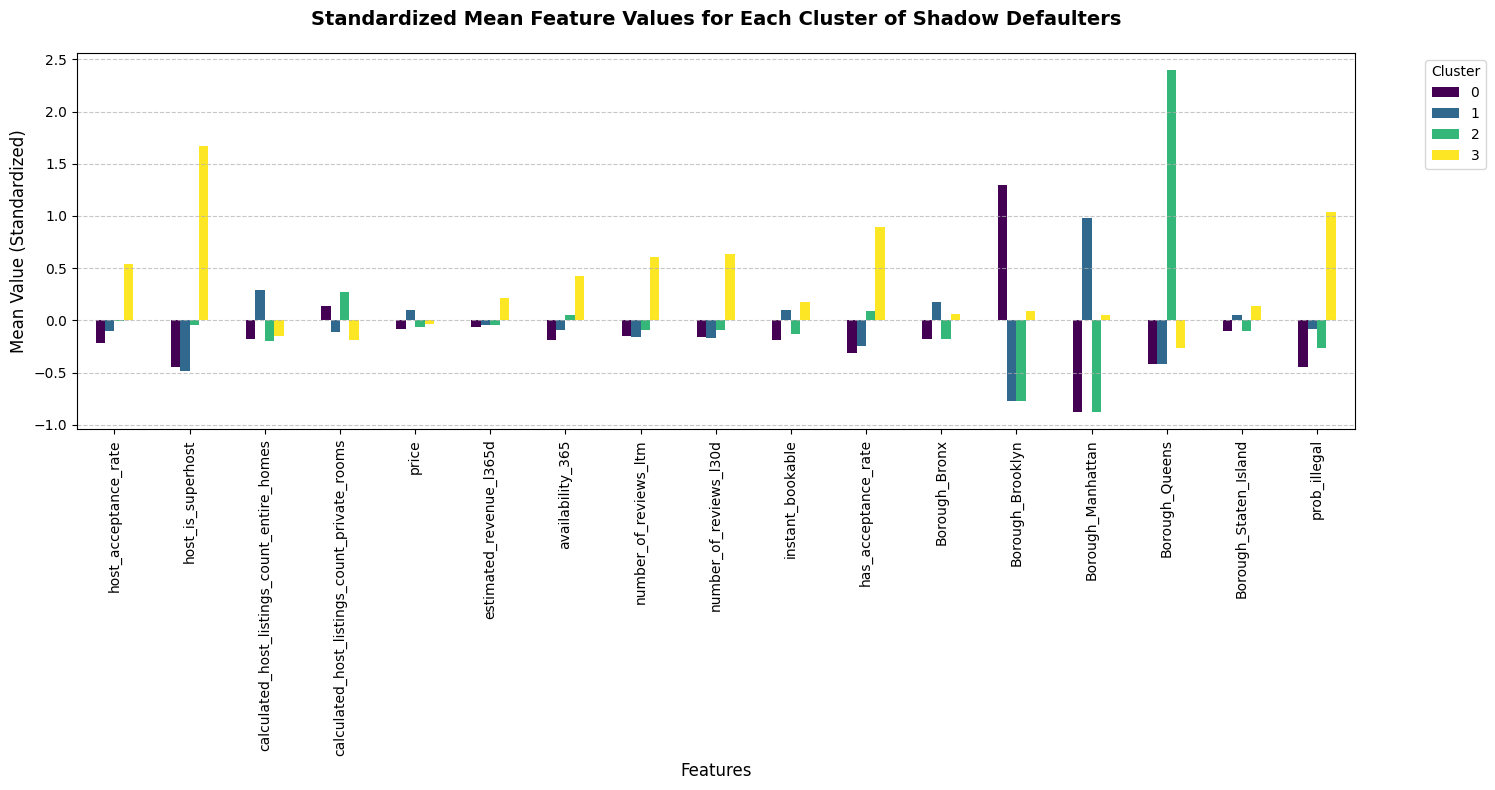

In [ ]:
from sklearn.cluster import KMeans

# 1. Identify the 'shadow defaulters' from the `final_audit_list`
# These are the listings deemed compliant but identified as high risk by the model
# `final_audit_list` already contains these (actual_label == 0).
shadow_defaulter_ids = final_audit_list['id'].unique()

# 2. Get the feature data (`X`) for these identified shadow defaulters
# Use the `model_df` to retrieve all features for these specific IDs
# `features` variable was defined previously and contains the predictor columns.
shadow_defaulter_features_df = model_df[model_df['id'].isin(shadow_defaulter_ids)][['id'] + features].copy()

# 3. Merge with `prob_illegal` from `final_audit_list`
# `prob_illegal` is a crucial characteristic for these 'shadow' listings
shadow_defaulter_profiles_df = pd.merge(
    shadow_defaulter_features_df,
    final_audit_list[['id', 'prob_illegal']],
    on='id',
    how='left'
)

# Set 'id' as index temporarily for cleaner feature selection and analysis
shadow_defaulter_profiles_df = shadow_defaulter_profiles_df.set_index('id')

# Define all features for clustering, including `prob_illegal`
clustering_features = features + ['prob_illegal']
X_cluster = shadow_defaulter_profiles_df[clustering_features]

print(f"Number of shadow defaulters for K-Means profiling: {len(X_cluster)}")
print("Features used for clustering:", X_cluster.columns.tolist())

# 4. Scale the data
# K-Means is sensitive to feature scales, so StandardScaler is used.
scaler_kmeans = StandardScaler()
X_scaled_kmeans = scaler_kmeans.fit_transform(X_cluster)
X_scaled_kmeans_df = pd.DataFrame(X_scaled_kmeans, columns=clustering_features, index=X_cluster.index)

# 5. Apply K-Means clustering
n_clusters = 4  # A common choice for profiling to get distinct, interpretable groups
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10) # n_init suppresses a warning
kmeans.fit(X_scaled_kmeans)

# Add cluster labels back to the original (unscaled) dataframe for easier interpretation
shadow_defaulter_profiles_df['Cluster'] = kmeans.labels_

# 6. Analyze clusters: Profile the characteristics of each cluster
cluster_profiles_unscaled = shadow_defaulter_profiles_df.groupby('Cluster').mean()

# Use the *scaled* data for plotting the profiles for better comparability
cluster_profiles_scaled = X_scaled_kmeans_df.copy()
cluster_profiles_scaled['Cluster'] = kmeans.labels_
cluster_profiles_scaled = cluster_profiles_scaled.groupby('Cluster').mean()

print("\n--- K-Means Cluster Profiles (Mean of Features) ---")
display(cluster_profiles_unscaled)

# Visualizing the cluster profiles using standardized values
plt.figure(figsize=(18, 10))
cluster_profiles_scaled.T.plot(kind='bar', figsize=(15, 8), colormap='viridis', ax=plt.gca())
plt.title('Standardized Mean Feature Values for Each Cluster of Shadow Defaulters', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Features', fontsize=12)
plt.ylabel('Mean Value (Standardized)', fontsize=12)
plt.xticks(rotation=90)
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
# Providing a more detailed textual interpretation
print("\n--- Interpretation of Shadow Defaulter Clusters ---")
overall_avg = X_cluster.mean()

for i in range(n_clusters):
    print(f"\n--- Cluster {i+1} (Count: {shadow_defaulter_profiles_df['Cluster'].value_counts()[i]}) ---")
    cluster_info = cluster_profiles_unscaled.loc[i]
    print(f"  Average Predicted Illegal Probability: {cluster_info['prob_illegal']:.4f}")

    print("  Key characteristics (compared to overall average of all shadow defaulters):")
    for feature in clustering_features:
        if feature == 'prob_illegal':
            continue # Already printed above

        cluster_val = cluster_info[feature]
        avg_val = overall_avg[feature]

        if pd.isna(cluster_val) or pd.isna(avg_val) or avg_val == 0: # Avoid division by zero or NaN
            continue

        diff_percent = ((cluster_val - avg_val) / avg_val) * 100

        # Define a threshold for 'significant' difference to highlight key features
        if abs(diff_percent) > 20: # Example: more than 20% difference from overall average
            status = "higher" if diff_percent > 0 else "lower"
            print(f"    - {feature}: {cluster_val:.2f} ({abs(diff_percent):.1f}% {status} than average)")
        else:
            print(f"    - {feature}: {cluster_val:.2f} (similar to average)")



--- Interpretation of Shadow Defaulter Clusters ---

--- Cluster 1 (Count: 10312) ---
  Average Predicted Illegal Probability: 0.0245
  Key characteristics (compared to overall average of all shadow defaulters):
    - host_acceptance_rate: 0.71 (similar to average)
    - host_is_superhost: 0.02 (91.7% lower than average)
    - calculated_host_listings_count_entire_homes: 13.07 (73.8% lower than average)
    - calculated_host_listings_count_private_rooms: 29.76 (61.3% higher than average)
    - price: 203.25 (57.2% lower than average)
    - estimated_revenue_l365d: 1715.91 (80.9% lower than average)
    - availability_365: 134.11 (similar to average)
    - number_of_reviews_ltm: 0.49 (85.1% lower than average)
    - number_of_reviews_l30d: 0.03 (86.4% lower than average)
    - instant_bookable: 0.13 (36.7% lower than average)
    - has_acceptance_rate: 0.40 (27.5% lower than average)
    - Borough_Bronx: 0.00 (100.0% lower than average)
    - Borough_Brooklyn: 1.00 (167.0% higher than 

#Output

In [ ]:
# --- Predict Probabilities on the 100% FULL Data (Out-of-Fold) ---
# This single line handles the 5-fold looping internally and ensures no data leakage.
# NOTE: Make sure to use the full 'X' and 'y' here, NOT 'X_test' and 'y_test'
print("Generating Out-of-Fold probabilities for the entire 36,000+ dataset...")
probs_full = cross_val_predict(best_model, X, y, cv=skf, method='predict_proba')[:, 1]

# --- Store IDs, Labels, and Probabilities ---
# Now we build the dataframe using the full model_df and the newly generated 100% probabilities
all_predictions = pd.DataFrame({
    'id': model_df['id'],             # Using the full model_df
    'host_id': model_df['host_id'],
    'actual_label': y,                # Using the full y
    'prob_illegal': probs_full
})

# Sort by risk (highest probability first) and reset the index
all_predictions = all_predictions.sort_values(by='prob_illegal', ascending=False).reset_index(drop=True)

print(f"Success! Total rows in all_predictions: {len(all_predictions)}")
display(all_predictions.head())

Generating Out-of-Fold probabilities for the entire 36,000+ dataset...
Success! Total rows in all_predictions: 36111


,id,host_id,actual_label,prob_illegal
0,980616234786854392,537135281,0,0.994752
1,624585985635107552,458591926,1,0.993954
2,980617449810787175,537135281,1,0.993742
3,624545561138818983,458591926,1,0.993659
4,1078336770127529285,557896176,1,0.993508


In [ ]:
# Export the master list of all predictions
all_predictions.to_csv('cross_val_predictions_all.csv', index=False)

files.download('cross_val_predictions_all.csv')
print("File has successfully been downloaded.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

File has successfully been downloaded.


With threshold:

In [ ]:
# ============================
threshold = 0.8  # <- set here
# ============================

# Filter for listings labeled '0' (Compliant) but predicted with high risk (>=threshold)
# These are our "Shadow" illegal listings / False Negatives
audit_targets = all_predictions[
    (all_predictions['actual_label'] == 0) & (all_predictions['prob_illegal'] >= threshold)
].copy()

audit_targets['risk_priority'] = 'High-Risk Audit'

print(f"Total Audit Targets Identified: {len(audit_targets)}")
print(f"These listings are labeled '0' but have an average illegal probability of {audit_targets['prob_illegal'].mean():.2%}")
display(audit_targets.head())

Total Audit Targets Identified: 551
These listings are labeled '0' but have an average illegal probability of 89.57%


,id,host_id,actual_label,prob_illegal,risk_priority
0,980616234786854392,537135281,0,0.994752,High-Risk Audit
67,1302785704600506643,471177409,0,0.991028,High-Risk Audit
88,35914632,269987340,0,0.990176,High-Risk Audit
110,1006681477271989960,370216107,0,0.989434,High-Risk Audit
112,431865,361855,0,0.989351,High-Risk Audit


In [ ]:
# Export the targeted list for auditing
file_name = f'shadow_illegal_audit_list_threshold_{threshold}.csv'

audit_targets.to_csv(file_name, index=False)

files.download(file_name)
print("File has successfully been downloaded.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

File has successfully been downloaded.


With Audit Capacity:

In [ ]:
# ==================================
audit_capacity = 1000  # <- set here
# ==================================

# Filter for listings labeled '0' (Compliant) first
surface_compliant = all_predictions[all_predictions['actual_label'] == 0].copy()

# Sort by highest risk and take the Top N based on our capacity limit
# These are our highest-priority "Shadow" illegal listings
audit_targets_capacity = surface_compliant.sort_values(by='prob_illegal', ascending=False).head(audit_capacity).copy()

# Assign a clear priority tag for the operational team
audit_targets_capacity['risk_priority'] = 'Capacity-Based Audit'

# Print summary statistics
print(f"Total Audit Targets Identified: {len(audit_targets_capacity)}")
print(f"These top {audit_capacity} listings are labeled '0' but have an average illegal probability of {audit_targets_capacity['prob_illegal'].mean():.2%}")
display(audit_targets_capacity.head())

Total Audit Targets Identified: 1000
These top 1000 listings are labeled '0' but have an average illegal probability of 80.75%


,id,host_id,actual_label,prob_illegal,risk_priority
0,980616234786854392,537135281,0,0.994752,Capacity-Based Audit
67,1302785704600506643,471177409,0,0.991028,Capacity-Based Audit
88,35914632,269987340,0,0.990176,Capacity-Based Audit
110,1006681477271989960,370216107,0,0.989434,Capacity-Based Audit
112,431865,361855,0,0.989351,Capacity-Based Audit


In [ ]:
# Export the targeted list for auditing
file_name_capacity = f'shadow_illegal_audit_list_capacity_{audit_capacity}.csv'

# Export the targeted list for auditing
audit_targets_capacity.to_csv(file_name_capacity, index=False)

# Trigger the download in Colab
files.download(file_name_capacity)
print(f"✅ Success! File '{file_name_capacity}' has successfully been downloaded.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Success! File 'shadow_illegal_audit_list_capacity_1000.csv' has successfully been downloaded.


Final Output for the following app

In [ ]:
all_compliant_risks = all_predictions[all_predictions['actual_label'] == 0].sort_values(by='prob_illegal', ascending=False)

all_compliant_risks = all_compliant_risks.merge(
    model_df[['id', 'latitude', 'longitude']],
    on='id',
    how='left'
)

# Display the first few rows to verify the new columns
print("Coordinates successfully added to the risk table:")
all_compliant_risks.head()

Coordinates successfully added to the risk table:


,id,host_id,actual_label,prob_illegal,latitude,longitude
0,980616234786854392,537135281,0,0.994752,40.760130,-73.958240
1,1302785704600506643,471177409,0,0.991028,40.741268,-73.977837
2,35914632,269987340,0,0.990176,40.743610,-73.997680
3,1006681477271989960,370216107,0,0.989434,40.734174,-73.995752
4,431865,361855,0,0.989351,40.834108,-73.939484


In [ ]:
# Export the risk of all compliant houses
all_compliant_risks.to_csv('all_compliant_listings_by_risk.csv', index=False)

files.download('all_compliant_listings_by_risk.csv')
print("File has successfully been downloaded.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

File has successfully been downloaded.
